# Setup

In [55]:
# ติดตั้ง library เพิ่มเติม
%pip install plotly kaleido -q

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ดาวน์โหลดฟอนต์ภาษาไทย (Sukhumvit-Medium)
!curl -L -o SukhumvitSet-Medium.ttf https://github.com/bluenex/baansuan_prannok/raw/master/fonts/sukhumvit-set/SukhumvitSet-Medium.ttf

# ตั้งค่า style
plt.rcParams['figure.dpi'] = 120

print('Setup Completed')

Note: you may need to restart the kernel to use updated packages.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 84932  100 84932    0     0   102k      0 --:--:-- --:--:-- --:--:--  102k
Setup Completed


In [56]:
# 1. Register the font file
font_path = 'SukhumvitSet-Medium.ttf'
mpl.font_manager.fontManager.addfont(font_path)

# 2. Find the actual internal name of the font
prop = mpl.font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print(f"Detected Font Name: {font_name}")

# 3. Set the parameters using the detected name
plt.rcParams['font.family'] = font_name
sns.set_theme(style="whitegrid", font=font_name)

# Optional: Fix minus signs showing as boxes in Thai fonts
plt.rcParams['axes.unicode_minus'] = False 

print('Setup Completed with font:', font_name)

Detected Font Name: Sukhumvit Set
Setup Completed with font: Sukhumvit Set


# เตรียมข้อมูล

In [57]:
df_2025 = pd.read_csv('uploads1-9-20260312-160940321.csv', encoding='utf-8-sig')
df_2026 = pd.read_csv('uploads1-9-20260312-160940030.csv', encoding='utf-8-sig')

In [58]:
print('='*60)
print('2025')
print(f'{df_2025.shape[0]:} rows | column {df_2025.shape[1]} columns')
print(f'columns : {df_2025.columns.tolist()}')

print('='*60)
print('2026')
print(f'{df_2026.shape[0]:} rows | column {df_2026.shape[1]} columns')
print(f'columns : {df_2026.columns.tolist()}')

print('='*60)
print('2025 Example :')
display(df_2025.head(3))
display(df_2025.tail(3))

print('='*60)

print('2026 Example :')
display(df_2026.head(3))
display(df_2026.tail(3))


2025
69440 rows | column 8 columns
columns : ['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน', 'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ']
2026
3010 rows | column 8 columns
columns : ['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน', 'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ']
2025 Example :


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,01/01/2025,คน,"127,551"
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,01/01/2025,คน,"8,218"
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),01/01/2025,คัน,"877,943"


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
69437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


2026 Example :


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,01/01/2026,คน,"112,325"
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,01/01/2026,คน,0
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),01/01/2026,คัน,"892,218"


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
3007,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ,11/03/2026,คน,"11,625"
3008,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาเข้าประเทศ,11/03/2026,คน,998
3009,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาออกประเทศ,11/03/2026,คน,"1,113"


In [59]:
df_2025.info()
print()
df_2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 69440 entries, 0 to 69439
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   รูปแบบการเดินทาง   15696 non-null  str  
 1   วัตถุประสงค์       15696 non-null  str  
 2   สาธารณะ/ส่วนบุคคล  15696 non-null  str  
 3   หน่วยงาน           15696 non-null  str  
 4   ยานพาหนะ/ท่า       15696 non-null  str  
 5   วันที่             15696 non-null  str  
 6   หน่วย              15696 non-null  str  
 7   ปริมาณ             15388 non-null  str  
dtypes: str(8)
memory usage: 4.2 MB

<class 'pandas.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   รูปแบบการเดินทาง   3010 non-null   str  
 1   วัตถุประสงค์       3010 non-null   str  
 2   สาธารณะ/ส่วนบุคคล  3010 non-null   str  
 3   หน่วยงาน           3010 non-null   str  
 4   ยานพาหนะ/ท่า       3010 non-nu

In [60]:
# เนื่องจากข้อมูลปริมาณที่ได้มามีลูกน้ำคั่น จึงทำให้นำตัวเลขนำมาใช้ยาก จึงแปลงมาให้เป็นตัวเลข Float ไม่มีลูกน้ำคั่น
df_2025['ปริมาณ'] = df_2025['ปริมาณ'].astype(str).str.replace(',', '').astype(float)
df_2026['ปริมาณ'] = df_2026['ปริมาณ'].astype(str).str.replace(',', '').astype(float)

# และเปลี่ยนวันที่ให้เหมาะสมกับการนำไปวิเคราะห์กับ pandas 
df_2025['วันที่'] = pd.to_datetime(df_2025['วันที่'], format='%d/%m/%Y')
df_2026['วันที่'] = pd.to_datetime(df_2026['วันที่'], format='%d/%m/%Y')

In [61]:
# สถิติเบื้องต้น
for year, df in [('2025', df_2025), ('2026', df_2026)]:
    total = int(df['ปริมาณ'].sum())
    null_count = df.isnull().sum().sum()
    pass_count = df['ปริมาณ'].nunique()
    mode_count = df['รูปแบบการเดินทาง'].nunique()
    purpose_count = df['วัตถุประสงค์'].nunique()
    station_count = df['ยานพาหนะ/ท่า'].nunique()

    print(f'ปี {year}')
    print(f'   จำนวนปริมาณ : {pass_count} คน')
    print(f'   รูปแบบการเดินทาง : {mode_count} แบบ')
    print(f'   วัตถุประสงค์การเดินทาง : {purpose_count} แบบ')
    print(f'   ยานพาหนะ/ท่า : {station_count} แบบ')
    print(f'   ⚠️ ค่า Null : {null_count} ค่า')
    print()

ปี 2025
   จำนวนปริมาณ : 12162 คน
   รูปแบบการเดินทาง : 4 แบบ
   วัตถุประสงค์การเดินทาง : 3 แบบ
   ยานพาหนะ/ท่า : 43 แบบ
   ⚠️ ค่า Null : 430260 ค่า

ปี 2026
   จำนวนปริมาณ : 2528 คน
   รูปแบบการเดินทาง : 4 แบบ
   วัตถุประสงค์การเดินทาง : 3 แบบ
   ยานพาหนะ/ท่า : 43 แบบ
   ⚠️ ค่า Null : 136 ค่า



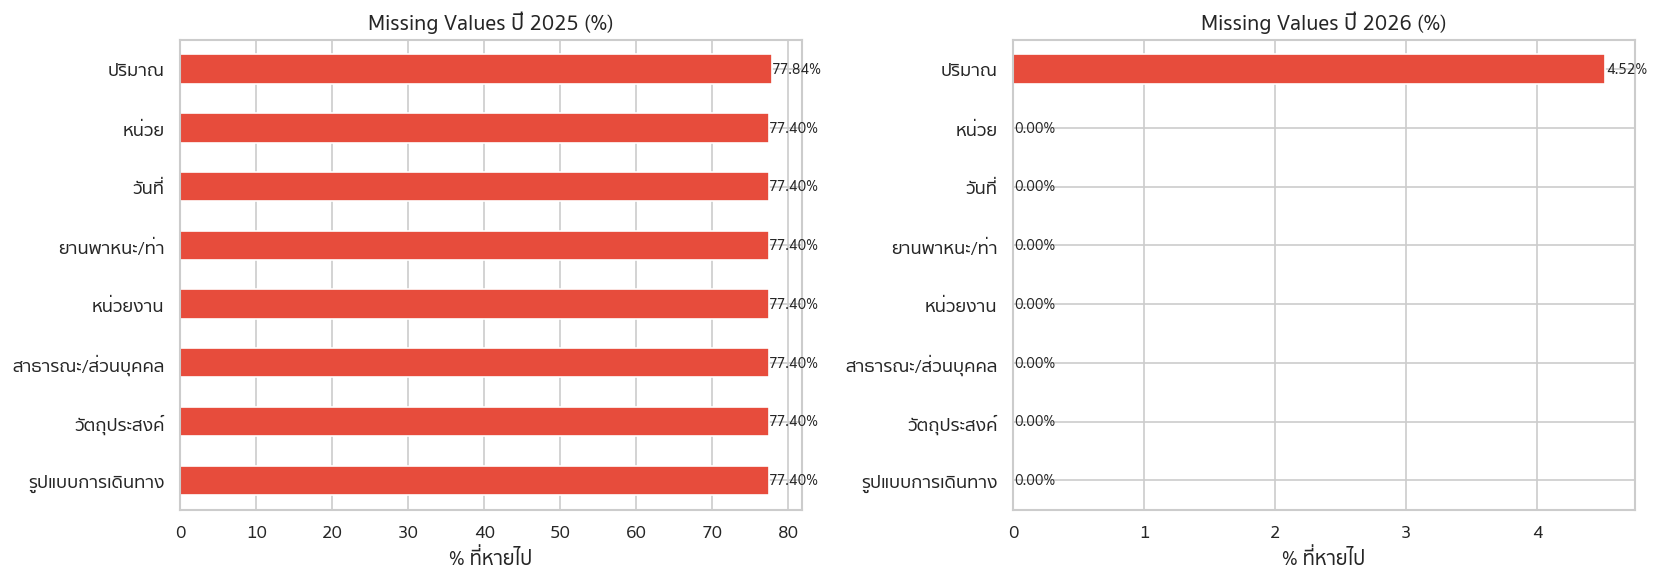

💡 แดง = มีค่า null


In [62]:
# ดู Missing Values แบบ Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (year, df) in zip(axes, [('2025', df_2025), ('2026', df_2026)]):
    null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in null_pct]
    null_pct.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Missing Values ปี {year} (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('% ที่หายไป')
    for i, v in enumerate(null_pct):
        ax.text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print('💡 แดง = มีค่า null' )

In [63]:
print('ประเภทการเดินทาง 2025')
print(df_2025['ยานพาหนะ/ท่า'].value_counts())

print('-'*50)
print('ประเภทการเดินทาง 2026')
print(df_2026['ยานพาหนะ/ท่า'].value_counts())

ประเภทการเดินทาง 2025
ยานพาหนะ/ท่า
ท่าอากาศยานภูมิภาค ขาออกประเทศ             366
รถ บขส. และ รถร่วม                         365
รถหมวด 3                                   365
รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ)            365
รถยนต์ทุกประเภท (10 จุดสำรวจ)              365
รถยนต์เฉพาะ 4 ล้อ (ทางด่วน)                365
รถยนต์ทุกประเภท (ทางด่วน)                  365
รถหมวด 4                                   365
รถเมล์ ขสมก.                               365
รถร่วม (หมวด 1)                            365
รถเอกชนเส้นปฏิรูป (หมวด 1)                 365
เรือด่วนเจ้าพระยา                          365
เรือคลองแสนแสบ                             365
เรือข้ามฟากเจ้าพระยา                       365
เรือไฟฟ้าเจ้าพระยา                         365
เรือภูมิภาค                                365
รถไฟ                                       365
รถไฟฟ้าสายสีน้ำเงิน                        365
รถไฟฟ้าสายสีม่วง                           365
รถไฟฟ้าสายสีเหลือง                         365
รถไฟฟ้าสายสีชมพู         

In [64]:
# เช็คว่าแต่ละ columm มีข้อมูลว่างเท่าไหร่
print('Null Data!!!!')
print('-'*50)


print('2025 : ')
print(df_2025.isnull().sum())

print('='*50)
print('2026 : ')
print(df_2026.isnull().sum())

Null Data!!!!
--------------------------------------------------
2025 : 
รูปแบบการเดินทาง     53744
วัตถุประสงค์         53744
สาธารณะ/ส่วนบุคคล    53744
หน่วยงาน             53744
ยานพาหนะ/ท่า         53744
วันที่               53744
หน่วย                53744
ปริมาณ               54052
dtype: int64
2026 : 
รูปแบบการเดินทาง       0
วัตถุประสงค์           0
สาธารณะ/ส่วนบุคคล      0
หน่วยงาน               0
ยานพาหนะ/ท่า           0
วันที่                 0
หน่วย                  0
ปริมาณ               136
dtype: int64


In [65]:
# ลบแถวที่ข้อมูลว่าง (NaN) ในคอลัมน์หลักออก
df_2025.dropna(subset=['รูปแบบการเดินทาง', 'ยานพาหนะ/ท่า', 'ปริมาณ'], inplace=True)
df_2026.dropna(subset=['รูปแบบการเดินทาง', 'ยานพาหนะ/ท่า', 'ปริมาณ'], inplace=True)

และสังเกตว่าข้อมูลปี 2026 มีข้อมูลที่เป็น null เฉพาะคอลลัมน์ปริมาณ ดังนั้นจึงทำการแทนค่า null ด้วยเลข 0

In [66]:
# แทนค่า NaN ในคอลัมน์ 'ปริมาณ' ด้วย 0
df_2026['ปริมาณ'] = df_2026['ปริมาณ'].fillna(0)

In [67]:
# เช็คว่าแต่ละ columm มีข้อมูลว่างเท่าไหร่
print('ตรวจสอบ Null Data อีกรอบ')
print('-'*50)


print('2025 : ')
print(df_2025.isnull().sum())

print('='*50)
print('2026 : ')
print(df_2026.isnull().sum())

ตรวจสอบ Null Data อีกรอบ
--------------------------------------------------
2025 : 
รูปแบบการเดินทาง     0
วัตถุประสงค์         0
สาธารณะ/ส่วนบุคคล    0
หน่วยงาน             0
ยานพาหนะ/ท่า         0
วันที่               0
หน่วย                0
ปริมาณ               0
dtype: int64
2026 : 
รูปแบบการเดินทาง     0
วัตถุประสงค์         0
สาธารณะ/ส่วนบุคคล    0
หน่วยงาน             0
ยานพาหนะ/ท่า         0
วันที่               0
หน่วย                0
ปริมาณ               0
dtype: int64


In [68]:
# รวมข้อมูลทั้งสองปีเข้าด้วยกัน
df_all = pd.concat([df_2025, df_2026], ignore_index=True)
df_all

,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,2025-01-01,คน,127551.0
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,2025-01-01,คน,8218.0
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),2025-01-01,คัน,877943.0
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),2025-01-01,คัน,932642.0
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),2025-01-01,คัน,1364992.0
...,...,...,...,...,...,...,...,...
18257,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานดอนเมือง ขาออกประเทศ,2026-03-11,คน,16641.0
18258,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาเข้าประเทศ,2026-03-11,คน,12741.0
18259,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ,2026-03-11,คน,11625.0
18260,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาเข้าประเทศ,2026-03-11,คน,998.0


In [69]:
rail_mapping = {
    'รถไฟฟ้า BTS': 'bts',
    'รถไฟฟ้าสายสีน้ำเงิน': 'mrt_blue',
    'รถไฟฟ้าสายสีม่วง': 'mrt_purple',
    'รถไฟฟ้าสายสีเหลือง': 'mrt_yellow',
    'รถไฟฟ้าสายสีชมพู': 'mrt_pink',
    'รถไฟฟ้า ARL': 'arl',
    'รถไฟฟ้าสายสีแดง': 'srt_red'
}

# สร้าง df ใหม่เฉพาะข้อมูลรฟฟ + เพิ่ม column rail_type เพื่อระบุประเภทของรฟฟ (สำหรับโจทย์ข้อ 1 และ 2)
df_rail = df_all[df_all['ยานพาหนะ/ท่า'].isin(rail_mapping.keys())].copy()
df_rail['rail_type'] = df_rail['ยานพาหนะ/ท่า'].map(rail_mapping)
df_rail

,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ,rail_type
16,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีน้ำเงิน,2025-01-01,คน,286892.0,mrt_blue
17,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีม่วง,2025-01-01,คน,34063.0,mrt_purple
18,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีเหลือง,2025-01-01,คน,29490.0,mrt_yellow
19,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีชมพู,2025-01-01,คน,33320.0,mrt_pink
20,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟฟท.,รถไฟฟ้า ARL,2025-01-01,คน,52281.0,arl
...,...,...,...,...,...,...,...,...,...
18237,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีเหลือง,2026-03-11,คน,48767.0,mrt_yellow
18238,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีชมพู,2026-03-11,คน,68115.0,mrt_pink
18239,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟฟท.,รถไฟฟ้า ARL,2026-03-11,คน,72565.0,arl
18240,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,กทม.,รถไฟฟ้า BTS,2026-03-11,คน,744699.0,bts


# โจทย์ที่ 1 : — คนไทยเดินทางด้วยอะไรมากที่สุด?

In [70]:
# แบ่งเป็นแต่ละวันคนขึ้นรฟฟแต่ละประเภทกี่คนบ้าง
df_first = df_rail.pivot_table(index='วันที่', columns='rail_type', values='ปริมาณ', aggfunc='sum').reset_index()
df_first.rename(columns={'วันที่': 'date'}, inplace=True)
df_first.fillna(0, inplace=True)
df_first.columns.name = None
df_first

,date,arl,bts,mrt_blue,mrt_pink,mrt_purple,mrt_yellow,srt_red
0,2025-01-01,52281.0,517968.0,286892.0,33320.0,34063.0,29490.0,24507.0
1,2025-01-02,61353.0,651144.0,383349.0,47248.0,57256.0,35138.0,30897.0
2,2025-01-03,63393.0,683558.0,397302.0,51312.0,62766.0,36856.0,32470.0
3,2025-01-04,50603.0,520834.0,294756.0,35089.0,40502.0,29004.0,24411.0
4,2025-01-05,51859.0,468745.0,259900.0,31910.0,35829.0,31899.0,25304.0
...,...,...,...,...,...,...,...,...
430,2026-03-07,60648.0,602389.0,332615.0,60923.0,43041.0,38963.0,29753.0
431,2026-03-08,54429.0,522979.0,294414.0,38889.0,35888.0,34597.0,26180.0
432,2026-03-09,74312.0,733760.0,442577.0,67658.0,68327.0,47112.0,40910.0
433,2026-03-10,74495.0,757836.0,479190.0,68203.0,73754.0,48547.0,40056.0


In [71]:
# 1. เตรียมคอลัมน์สำหรับกลุ่ม MRT
mrt_columns = ['mrt_blue', 'mrt_pink', 'mrt_purple', 'mrt_yellow']

# 2. สร้างคอลัมน์ใหม่ 'mrt_total' และลบคอลัมน์ย่อยออก (เพื่อลดความซับซ้อน)
df_first['mrt_total'] = df_first[mrt_columns].sum(axis=1)

# 3. เลือกคอลัมน์ที่ต้องการใช้งานจริง
final_columns = ['date', 'arl', 'bts', 'srt_red', 'mrt_total']
df_combined = df_first[final_columns].copy()

# 4. กรองเฉพาะเดือน มกราคม (1) และ กุมภาพันธ์ (2)
df_combined['date'] = pd.to_datetime(df_combined['date'])
df_filtered = df_combined[df_combined['date'].dt.month.isin([1, 2])].copy()
df_filtered['Year'] = df_filtered['date'].dt.year

# 5. สรุปผลรายปี
summary_by_year = df_filtered.groupby('Year')[['arl', 'bts', 'srt_red', 'mrt_total']].sum()

# 6. คำนวณส่วนต่างและ % Growth
comparison = summary_by_year.T
comparison['Difference'] = comparison[2026] - comparison[2025]
comparison['% Growth'] = (comparison['Difference'] / comparison[2025]) * 100

print("--- สรุปข้อมูลผู้โดยสารรวม MRT (ม.ค. - ก.พ.) ---")
print(comparison.round(2))

--- สรุปข้อมูลผู้โดยสารรวม MRT (ม.ค. - ก.พ.) ---
Year             2025        2026  Difference  % Growth
arl         4236553.0   4268056.0     31503.0      0.74
bts        46973721.0  42699972.0  -4273749.0     -9.10
srt_red     2225785.0   2244857.0     19072.0      0.86
mrt_total  38436594.0  37131748.0  -1304846.0     -3.39


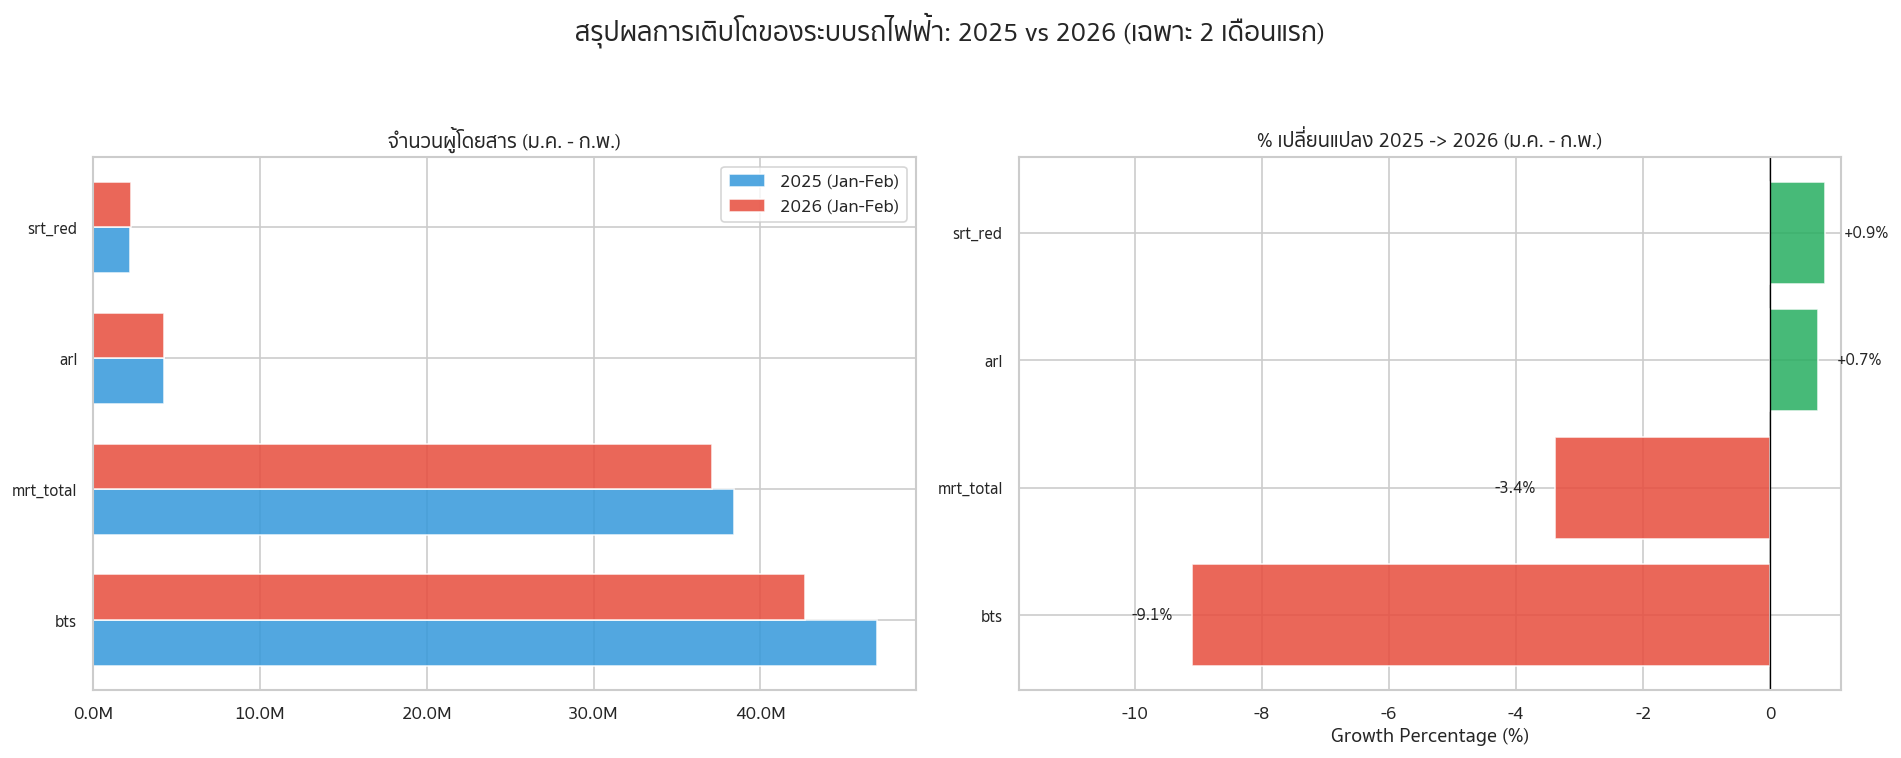

In [72]:
# 1. กรองข้อมูลเฉพาะเดือน ม.ค. - ก.พ. และปีที่ต้องการ
df_filtered = df_first[df_first['date'].dt.month.isin([1, 2])].copy()
df_filtered['Year'] = df_filtered['date'].dt.year

# 2. จัดกลุ่มข้อมูล (Groupby) ตามปี และรวมสายรถไฟฟ้า
# (หากคุณยังไม่ได้รวม MRT สามารถใช้คำสั่ง df_rail['mrt_total'] = ... ก่อนหน้านี้ได้ครับ)
by_line = df_filtered.groupby('Year')[['arl', 'bts', 'srt_red', 'mrt_total']].sum().T

# 3. คำนวณ % Change
by_line['change_pct'] = ((by_line[2026] - by_line[2025]) / by_line[2025]) * 100
by_line = by_line.sort_values('change_pct', ascending=True)

# 4. สร้างกราฟ 2 ฝั่ง (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(by_line))
w = 0.35

# กราฟด้านซ้าย: จำนวนผู้โดยสารรวม (Bar Chart)
axes[0].barh(x - w/2, by_line[2025], w, label='2025 (Jan-Feb)', color='#3498db', alpha=0.85)
axes[0].barh(x + w/2, by_line[2026], w, label='2026 (Jan-Feb)', color='#e74c3c', alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(by_line.index, fontsize=10)
axes[0].set_title('จำนวนผู้โดยสาร (ม.ค. - ก.พ.)', fontweight='bold')
axes[0].legend()
# ปรับตัวเลขแกน X ให้ดูง่าย (หารด้วย 1 ล้าน และเติม M หรือใช้ 1k แล้วแต่ปริมาณข้อมูล)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# กราฟด้านขวา: % Change
colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in by_line['change_pct']]
axes[1].barh(x, by_line['change_pct'], color=colors, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_yticks(x)
axes[1].set_yticklabels(by_line.index, fontsize=10)
axes[1].set_title('% เปลี่ยนแปลง 2025 -> 2026 (ม.ค. - ก.พ.)', fontweight='bold')
axes[1].set_xlabel('Growth Percentage (%)')

min_val = by_line['change_pct'].min()
max_val = by_line['change_pct'].max()
axes[1].set_xlim(min_val * 1.3, max_val * 1.3)

# ใส่ตัวเลข % กำกับที่ปลายแท่ง
for i, v in enumerate(by_line['change_pct']):
    offset = 0.3 if v >= 0 else -0.3
    align = 'left' if v >= 0 else 'right'
    axes[1].text(v + offset, i, f'{v:+.1f}%', 
                va='center', ha='left' if v >= 0 else 'right', 
                fontsize=10, fontweight='bold')

plt.suptitle('สรุปผลการเติบโตของระบบรถไฟฟ้า: 2025 vs 2026 (เฉพาะ 2 เดือนแรก)', 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [73]:
print(df_first)

          date      arl       bts  mrt_blue  mrt_pink  mrt_purple  mrt_yellow  \
0   2025-01-01  52281.0  517968.0  286892.0   33320.0     34063.0     29490.0   
1   2025-01-02  61353.0  651144.0  383349.0   47248.0     57256.0     35138.0   
2   2025-01-03  63393.0  683558.0  397302.0   51312.0     62766.0     36856.0   
3   2025-01-04  50603.0  520834.0  294756.0   35089.0     40502.0     29004.0   
4   2025-01-05  51859.0  468745.0  259900.0   31910.0     35829.0     31899.0   
..         ...      ...       ...       ...       ...         ...         ...   
430 2026-03-07  60648.0  602389.0  332615.0   60923.0     43041.0     38963.0   
431 2026-03-08  54429.0  522979.0  294414.0   38889.0     35888.0     34597.0   
432 2026-03-09  74312.0  733760.0  442577.0   67658.0     68327.0     47112.0   
433 2026-03-10  74495.0  757836.0  479190.0   68203.0     73754.0     48547.0   
434 2026-03-11  72565.0  744699.0  476734.0   68115.0     73149.0     48767.0   

     srt_red  mrt_total  
0

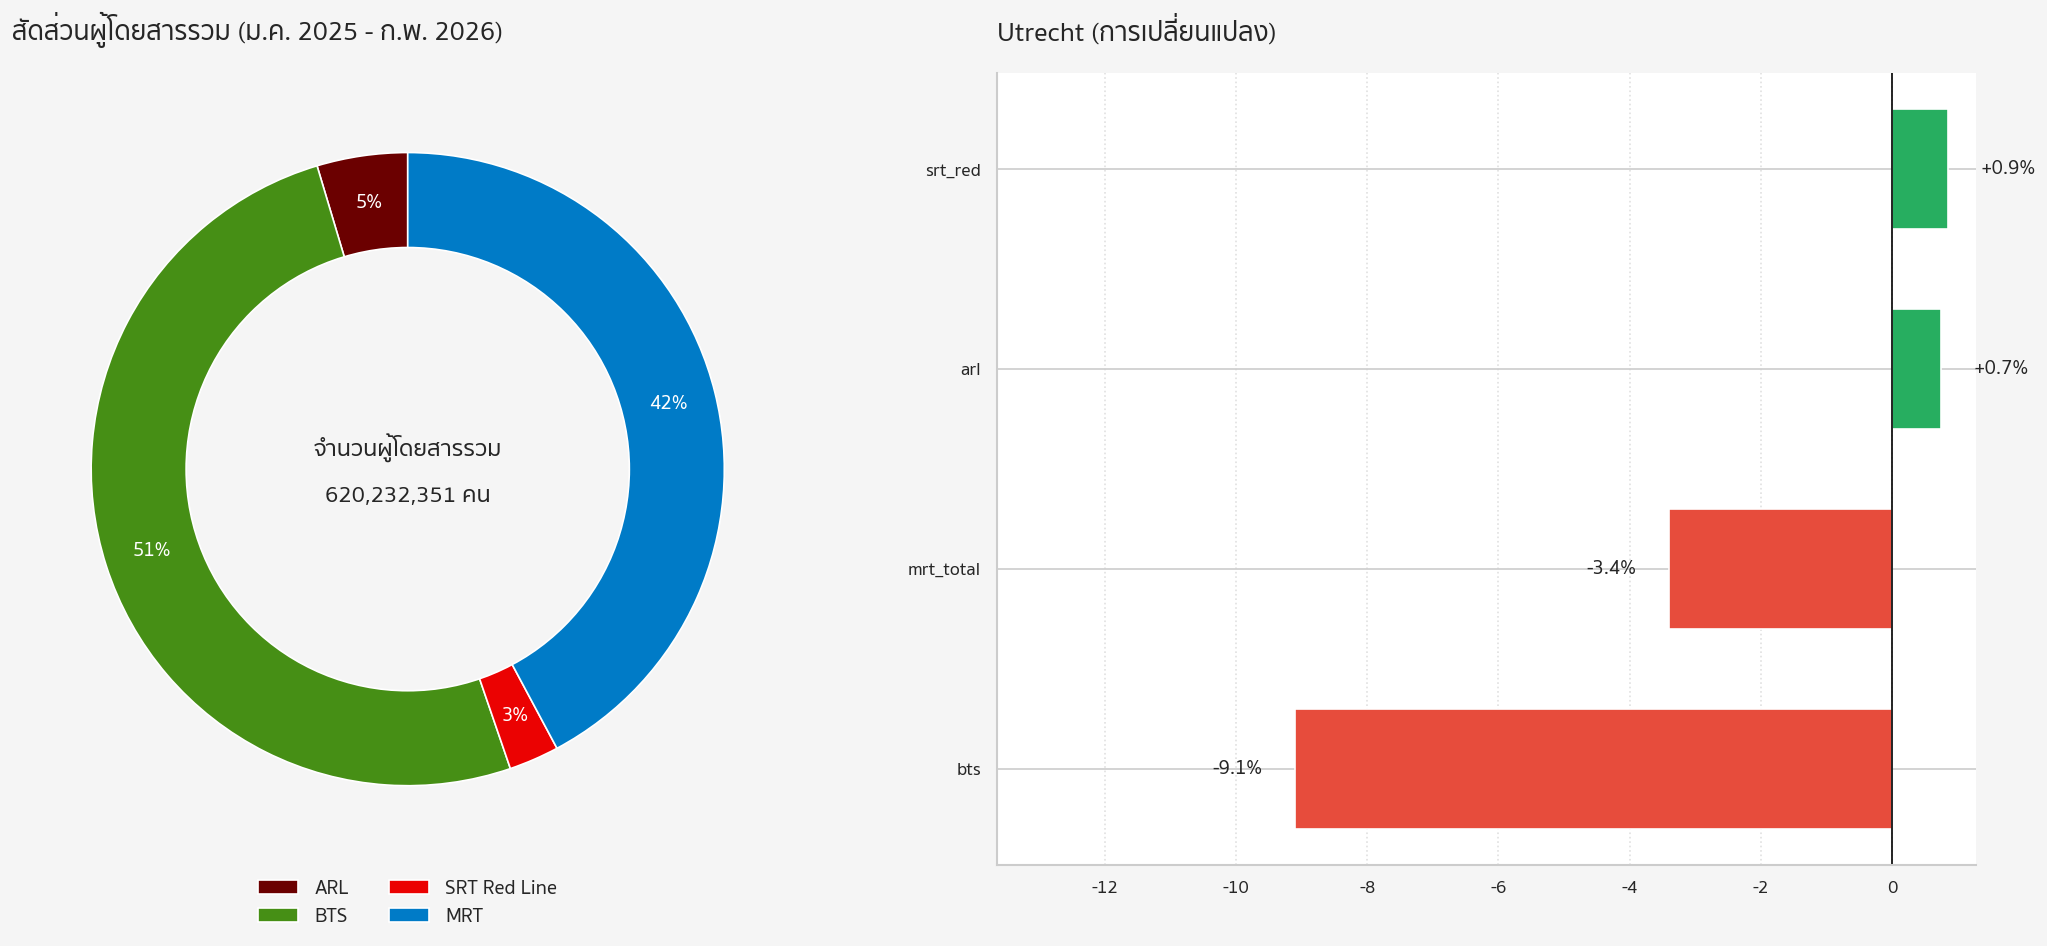

In [74]:
target_columns = ['arl', 'bts', 'srt_red', 'mrt_total']
total_values = df_first[target_columns].sum()

labels = ['ARL', 'BTS', 'SRT Red Line', 'MRT']
colors_donut = ['#6B0000', '#468f15', '#EB0202', '#007bc7']

# 2. สร้าง Figure และ Subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#f5f5f5') # พื้นหลังเทาอ่อนตามรูป

# --- กราฟซ้าย: Donut Chart (สัดส่วนรวมทุกปี) ---
# ใช้ total_values ที่เรา sum ไว้
wedges, texts, autotexts = axes[0].pie(
    total_values, 
    autopct='%1.0f%%', 
    startangle=90, 
    colors=colors_donut,
    pctdistance=0.85,
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'} # เปลี่ยนเป็นสีขาวให้อ่านง่ายบนพื้นสีเข้ม
)

# สร้างวงกลมตรงกลาง (Donut hole)
centre_circle = plt.Circle((0,0), 0.70, fc='#f5f5f5')
axes[0].add_artist(centre_circle)

# เพิ่มข้อความตรงกลาง Donut (Optional: บอกยอดรวมทั้งหมด)
total_all_systems = total_values.sum()
axes[0].text(0, 0, f'จำนวนผู้โดยสารรวม\n\n{total_all_systems:,.0f} คน', 
             ha='center', va='center', fontsize=14, fontweight='bold')

axes[0].set_title('สัดส่วนผู้โดยสารรวม (ม.ค. 2025 - ก.พ. 2026)', loc='left', fontsize=16, fontweight='bold', pad=20)

# Legend ด้านล่าง
axes[0].legend(wedges, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1),
              ncol=2, frameon=False, fontsize=12)

# --- กราฟขวา: % Change (แท่งแนวนอน) ---
by_line_sorted = by_line.sort_values('change_pct', ascending=True)
y_pos = np.arange(len(by_line_sorted))
growth_colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in by_line_sorted['change_pct']]

axes[1].barh(y_pos, by_line_sorted['change_pct'], color=growth_colors, height=0.6)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(by_line_sorted.index, fontsize=11)
axes[1].set_title('Utrecht (การเปลี่ยนแปลง)', loc='left', fontsize=16, fontweight='bold', pad=20)

# ปรับขอบเขตแกน X และเอาเส้นกรอบออกบางส่วนให้เหมือนรูป
axes[1].set_xlim(min(by_line_sorted['change_pct'])*1.5, max(by_line_sorted['change_pct'])*1.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='x', linestyle=':', alpha=0.6)

# ใส่ตัวเลข % กำกับปลายแท่ง
for i, v in enumerate(by_line_sorted['change_pct']):
    offset = 0.5 if v >= 0 else -0.5
    align = 'left' if v >= 0 else 'right'
    axes[1].text(v + offset, i, f'{v:+.1f}%', va='center', ha=align, fontweight='bold')

plt.tight_layout()
plt.show()

# โจทย์ 2 : — รถไฟฟ้าในกรุงเทพฯ แต่ละสายมีพฤติกรรมผู้โดยสารต่างกันอย่างไร?

In [75]:
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable


labels = ['ARL', 'BTS', 'MRT Blue', 'MRT Pink', 'MRT Purple', 'MRT Yellow', 'SRT Red']
plot_cols = ['arl', 'bts', 'mrt_blue', 'mrt_pink', 'mrt_purple', 'mrt_yellow', 'srt_red']

color_map = {
    'arl': '#6B0000',
    'bts': '#468f15',
    'mrt_blue': '#191970',
    'mrt_pink': '#FF69B4',
    'mrt_purple': '#800080',
    'mrt_yellow': '#FFD700',
    'srt_red': '#EB0202'
}

ปริมาณผู้โดยสารของแต่ละสาย

In [76]:
def heatmap():
    df_heat = df_first.copy()
    df_heat['date'] = pd.to_datetime(df_heat['date'])
    df_heat['day_of_week'] = df_heat['date'].dt.day_name()

    df_melted = df_heat.melt(id_vars=['day_of_week'], value_vars=plot_cols, 
                            var_name='line', value_name='passengers')

    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    ct_heatmap = pd.crosstab(index=df_melted['line'], 
                            columns=df_melted['day_of_week'], 
                            values=df_melted['passengers'], 
                            aggfunc='mean').reindex(columns=days_order)

    ct_heatmap = ct_heatmap / 1000
    ct_heatmap.index = [i.upper().replace('_', ' ') for i in ct_heatmap.index]
    return ct_heatmap

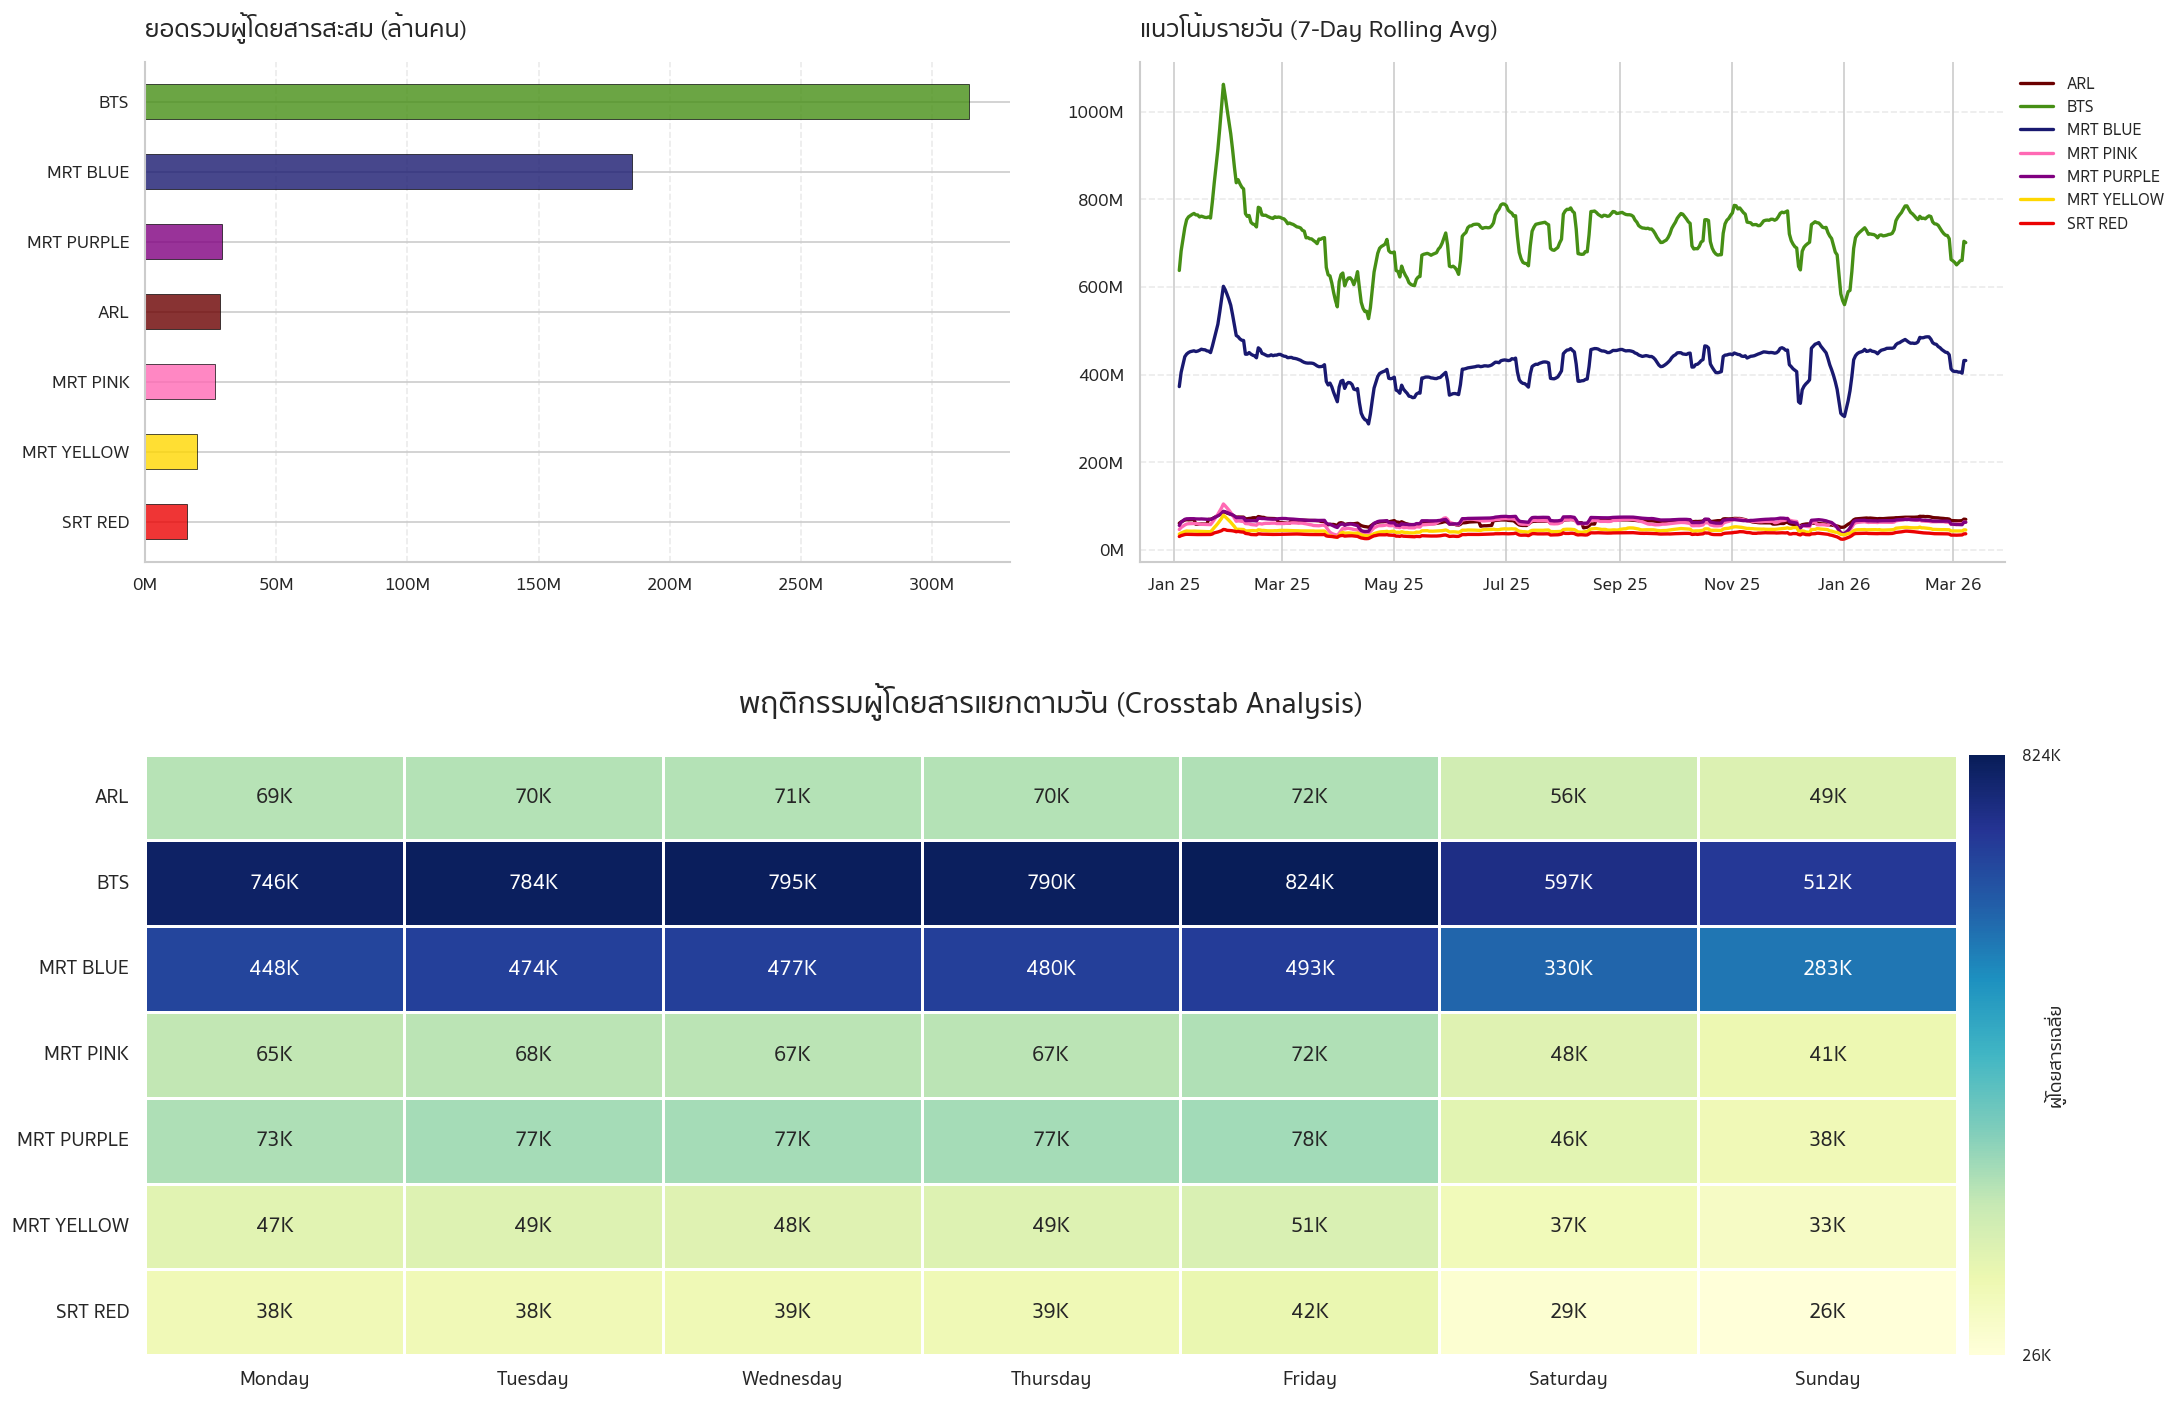

In [77]:
# --- สร้าง figure ---
fig = plt.figure(figsize=(20, 14), constrained_layout=False)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.15)

ax_bar = fig.add_subplot(gs[0, 0])
ax_line = fig.add_subplot(gs[0, 1])
ax_heat = fig.add_subplot(gs[1, :])

# --- Bar Chart  ---
total_m = (df_first[plot_cols].sum().sort_values() / 1_000_000)
labels = [c.upper().replace('_', ' ') for c in total_m.index]
colors = [color_map[c] for c in total_m.index]

bars = ax_bar.barh(labels, total_m, color=colors, height=0.5, edgecolor='black', linewidth=0.5, alpha=0.8)
ax_bar.set_title('ยอดรวมผู้โดยสารสะสม (ล้านคน)', fontsize=15, fontweight='bold', loc='left', pad=15)
ax_bar.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:g}M'))
ax_bar.grid(axis='x', linestyle='--', alpha=0.4)
ax_bar.tick_params(axis='both', which='major', labelsize=11)


# --- Line Chart ---
for col in plot_cols:
    rolling = (df_first[col] / 1_000).rolling(window=7, center=True).mean()
    ax_line.plot(df_first['date'], rolling, color=color_map[col], label=col.upper().replace('_', ' '), linewidth=2)

ax_line.set_title('แนวโน้มรายวัน (7-Day Rolling Avg)', fontsize=15, fontweight='bold', loc='left', pad=15)
ax_line.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:g}M'))
ax_line.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax_line.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=10)
ax_line.grid(axis='y', linestyle='--', alpha=0.4)

# --- Heat Map ---
ct_heatmap = heatmap()
vmin = ct_heatmap.values.min()
vmax = ct_heatmap.values.max()
annot_text = ct_heatmap.map(lambda x: f"{int(x)}K")

divider = make_axes_locatable(ax_heat)
cax = divider.append_axes("right", size="2%", pad=0.1)

sns.heatmap(ct_heatmap, 
            annot=annot_text,
            fmt="",
            cmap="YlGnBu", 
            norm=LogNorm(),
            ax=ax_heat,
            cbar_ax=cax,
            annot_kws={"size": 13, "weight": "bold"},
            linewidths=1.5,
            linecolor='white')

# Colorbar Setting
cax.set_yticks([vmin, vmax])

# Line Remove
cax.set_yticklabels([f'{int(vmin)}K', f'{int(vmax)}K'])
cax.tick_params(axis='y', which='both', length=0, width=0)
cax.yaxis.set_minor_locator(ticker.NullLocator())
cax.set_yticks([vmin, vmax])
cax.set_yticklabels([f'{int(vmin)}K', f'{int(vmax)}K'])

for spine in cax.spines.values():
    spine.set_visible(False)

# ปรับรายละเอียดอื่นๆ ของ Colorbar ตามเดิม
cax.set_ylabel('ผู้โดยสารเฉลี่ย', fontsize=11, fontweight='bold', labelpad=-10)
cax.yaxis.set_tick_params(labelsize=10, pad=10)

# ปรับรายละเอียดรอบๆ Heatmap
ax_heat.set_title('พฤติกรรมผู้โดยสารแยกตามวัน (Crosstab Analysis)', fontsize=18, fontweight='bold', pad=25)
ax_heat.set_xlabel('', fontsize=12)
ax_heat.set_ylabel('', fontsize=12)
ax_heat.tick_params(axis='x', labelsize=12, rotation=0)
ax_heat.tick_params(axis='y', labelsize=12, rotation=0)

# ลบแกนที่ไม่จำเป็นออก (Spines)
for ax in [ax_bar, ax_line]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

cbar = ax_heat.collections[0].colorbar
cbar.outline.set_visible(False)

plt.show()

In [78]:
lines = ['arl', 'bts', 'mrt_blue', 'mrt_pink', 'mrt_purple', 'mrt_yellow', 'srt_red']
df_lines = df_first[lines]

# 1. คำนวณค่าเฉลี่ย (Mean) และ ส่วนเบี่ยงเบนมาตรฐาน (Std)
analysis = pd.DataFrame({
    'mean_ridership': df_lines.mean(),
    'std_dev': df_lines.std()
})

# 2. คำนวณ Coefficient of Variation (CV)
analysis['cv_percentage'] = (analysis['std_dev'] / analysis['mean_ridership']) * 100

# 3. จัดลำดับ
analysis = analysis.sort_values(by='cv_percentage', ascending=False)

print("--- ผลการวิเคราะห์ความผันผวน (เรียงจากผันผวนมากไปน้อย) ---")
print(analysis[['mean_ridership', 'cv_percentage']].round(2))

# สรุปผล
most_volatile = analysis.index[0]
most_stable = analysis.index[-1]

print(f"\nสายที่มีความผันผวนสูงสุด: {most_volatile.upper()} (CV = {analysis.loc[most_volatile, 'cv_percentage']:.2f}%)")
print(f"สายที่มีความเสถียรที่สุด: {most_stable.upper()} (CV = {analysis.loc[most_stable, 'cv_percentage']:.2f}%)")

--- ผลการวิเคราะห์ความผันผวน (เรียงจากผันผวนมากไปน้อย) ---
            mean_ridership  cv_percentage
mrt_purple        67298.50          29.29
mrt_pink          61681.65          26.98
mrt_blue         427071.85          23.97
mrt_yellow        45446.04          22.18
srt_red           36465.60          20.41
bts              721925.17          20.29
arl               65932.68          20.09

สายที่มีความผันผวนสูงสุด: MRT_PURPLE (CV = 29.29%)
สายที่มีความเสถียรที่สุด: ARL (CV = 20.09%)


# โจทย์ 3 - วันหยุดและเทศกาลเห็นได้ในข้อมูลไหม?

In [79]:
df_all

,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,2025-01-01,คน,127551.0
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,2025-01-01,คน,8218.0
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),2025-01-01,คัน,877943.0
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),2025-01-01,คัน,932642.0
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),2025-01-01,คัน,1364992.0
...,...,...,...,...,...,...,...,...
18257,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานดอนเมือง ขาออกประเทศ,2026-03-11,คน,16641.0
18258,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาเข้าประเทศ,2026-03-11,คน,12741.0
18259,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ,2026-03-11,คน,11625.0
18260,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาเข้าประเทศ,2026-03-11,คน,998.0


In [80]:
# แปลงวันที่และตั้งเป็น Index
df_all['วันที่'] = pd.to_datetime(df_all['วันที่'])
daily_data = df_all.groupby('วันที่')['ปริมาณ'].sum().reset_index()

# สร้าง Feature ด้านเวลาเพื่อดูความนิ่งของข้อมูล
daily_data['day_of_week'] = daily_data['วันที่'].dt.day_name()
daily_data['is_weekend'] = daily_data['วันที่'].dt.dayofweek >= 5

In [81]:
daily_data

,วันที่,ปริมาณ,day_of_week,is_weekend
0,2025-01-01,6674990.0,Wednesday,False
1,2025-01-02,6989121.0,Thursday,False
2,2025-01-03,7743758.0,Friday,False
3,2025-01-04,7146715.0,Saturday,True
4,2025-01-05,7035727.0,Sunday,True
...,...,...,...,...
430,2026-03-07,5727336.0,Saturday,True
431,2026-03-08,4932783.0,Sunday,True
432,2026-03-09,6190960.0,Monday,False
433,2026-03-10,6313884.0,Tuesday,False


In [82]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [83]:
from statsmodels.tsa.seasonal import seasonal_decompose

# แยกองค์ประกอบ (Period=7 สำหรับข้อมูลรายวันที่มีรอบสัปดาห์)
result = seasonal_decompose(daily_data.set_index('วันที่')['ปริมาณ'], model='additive', period=7)

# ส่วนที่เป็น Residual นี่แหละคือ "จุดที่อธิบายไม่ได้ด้วยวงจรปกติ"
daily_data['residual'] = result.resid

In [84]:
%pip install holidays

Note: you may need to restart the kernel to use updated packages.


In [85]:
import holidays
import pandas as pd

# สร้าง Object วันหยุดของประเทศไทย
th_holidays = holidays.Thailand(years=[2025, 2026])

# ฟังก์ชันสำหรับระบุชื่อวันหยุด
def get_holiday_name(date):
    return th_holidays.get(date)

# นำไปใช้กับ DataFrame
daily_data['holiday_name'] = daily_data['วันที่'].map(get_holiday_name)
daily_data['is_holiday'] = daily_data['holiday_name'].notna()

In [92]:
def get_anomaly_insight(df, target_date):
    # 1. กรองข้อมูลเฉพาะวันที่เกิด Anomaly
    target_date = pd.to_datetime(target_date)
    anomaly_day_data = df[df['วันที่'] == target_date]
    
    # 2. หาค่าเฉลี่ยปกติของ "วันในสัปดาห์" เดียวกัน (เช่น ค่าเฉลี่ยของวันจันทร์อื่นๆ)
    # เพื่อใช้เป็น Baseline ในการเปรียบเทียบ
    day_of_week = target_date.dayofweek
    baseline_days = df[(df['วันที่'].dt.dayofweek == day_of_week) & (df['วันที่'] != target_date)]
    
    # คำนวณค่าเฉลี่ยแยกตามหน่วยงานและประเภทรถ (Baseline)
    baseline_avg = baseline_days.groupby(['หน่วยงาน', 'ยานพาหนะ/ท่า'])['ปริมาณ'].mean().reset_index()
    baseline_avg.rename(columns={'ปริมาณ': 'avg_volume'}, inplace=True)
    
    # 3. นำข้อมูลวันที่มีปัญหามา Merge กับค่าเฉลี่ย Baseline
    insight_df = anomaly_day_data.groupby(['หน่วยงาน', 'ยานพาหนะ/ท่า', 'รูปแบบการเดินทาง'])['ปริมาณ'].sum().reset_index()
    insight_df = pd.merge(insight_df, baseline_avg, on=['หน่วยงาน', 'ยานพาหนะ/ท่า'], how='left')
    
    # 4. คำนวณส่วนต่าง (Diff) และ % ที่เพิ่มขึ้น
    insight_df['diff'] = insight_df['ปริมาณ'] - insight_df['avg_volume']
    insight_df['percent_increase'] = (insight_df['diff'] / insight_df['avg_volume']) * 100
    
    # 5. เรียงลำดับดูตัวที่ "ส่งผลกระทบมากที่สุด" (Top Contributors)
    top_contributors = insight_df.sort_values(by='diff', ascending=False).head(10)
    
    return top_contributors

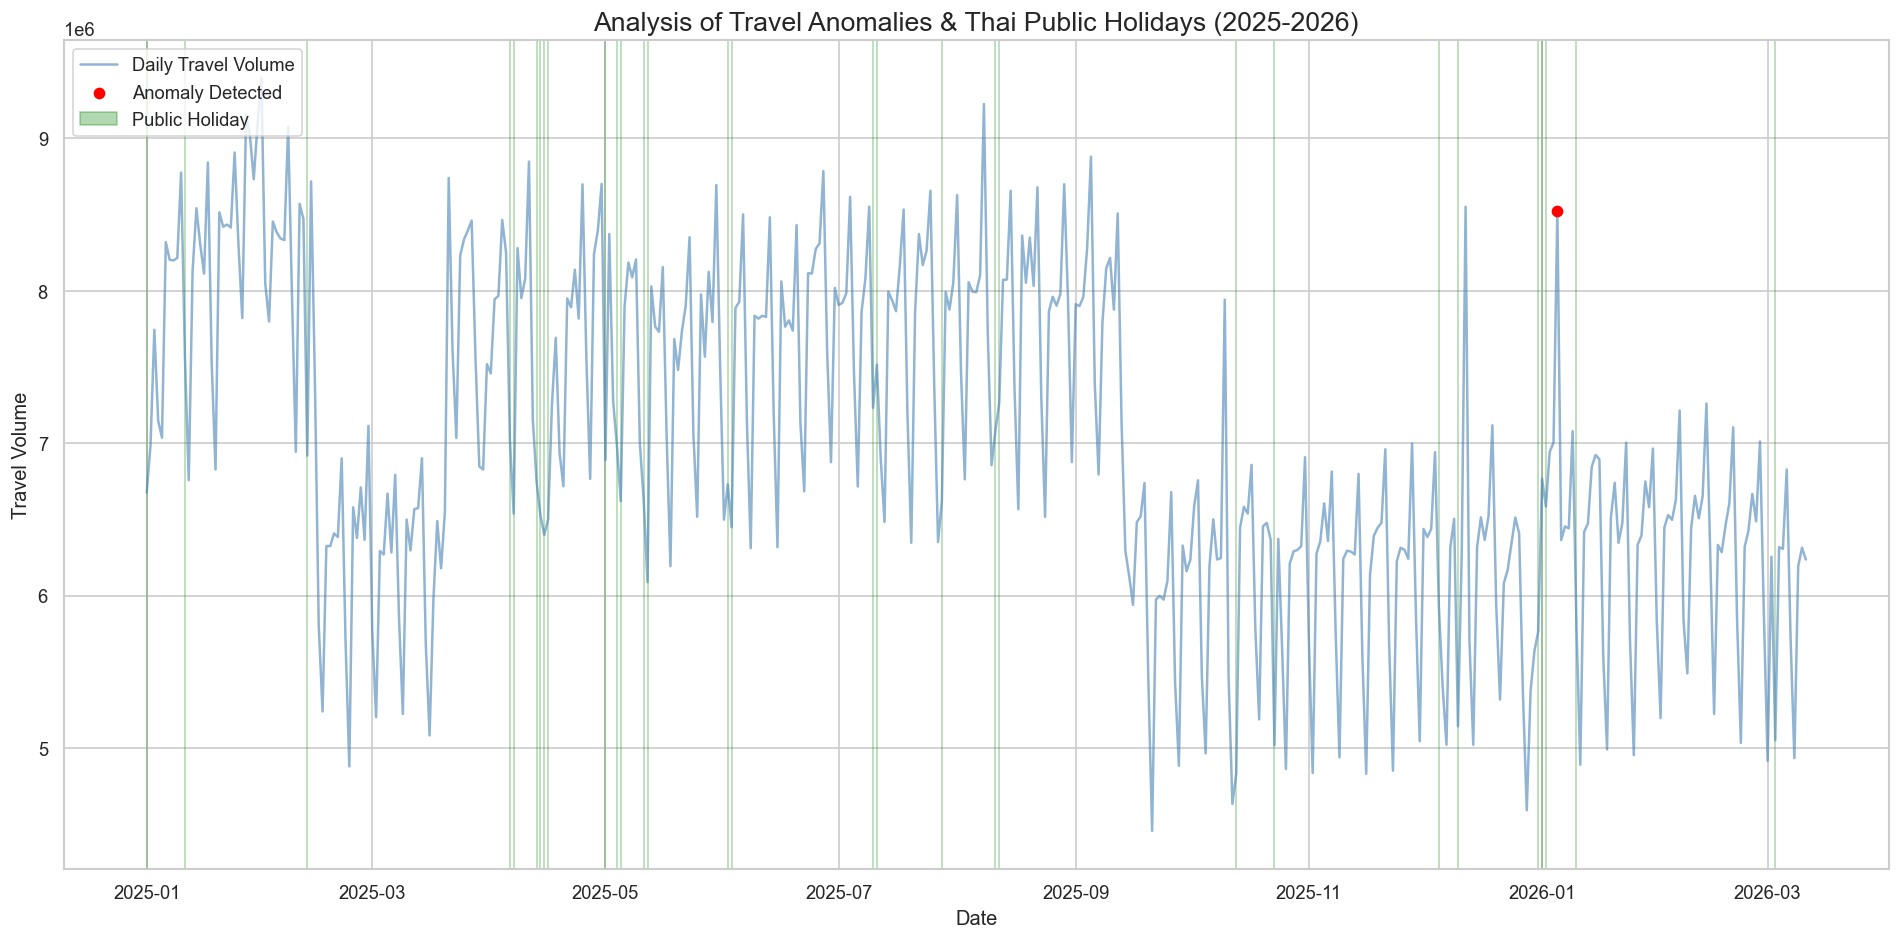

--- Deep Dive: Anomaly Insights (Top 10) ---

วันที่พบความผิดปกติ: 2026-01-05 (วันปกติ)
Z-Score: 2.14
   หน่วยงาน                     ยานพาหนะ/ท่า           diff  percent_increase
1      กทพ.      รถยนต์เฉพาะ 4 ล้อ (ทางด่วน)  242442.540984         16.314655
0      กทพ.        รถยนต์ทุกประเภท (ทางด่วน)  199059.950820         12.898172
20      ทล.    รถยนต์ทุกประเภท (10 จุดสำรวจ)   78424.064516          8.110139
21      ทล.  รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ)   61246.903226          7.454434
7       ขบ.       รถเอกชนเส้นปฏิรูป (หมวด 1)   48326.360656         14.107389
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. การเตรียมข้อมูล (Preprocessing)
# สมมติว่า df_all คือ DataFrame ที่คุณมีอยู่
df_all['วันที่'] = pd.to_datetime(df_all['วันที่'])
daily_df = df_all.groupby('วันที่')['ปริมาณ'].sum().reset_index()
daily_df = daily_df.sort_values('วันที่')

# 2. การดึงข้อมูลวันหยุดไทย (Event Mapping)
# ดึงวันหยุดปี 2025 และ 2026
th_holidays = holidays.Thailand(years=[2025, 2026])
daily_df['holiday_name'] = daily_df['วันที่'].apply(lambda x: th_holidays.get(x))
daily_df['is_holiday'] = daily_df['holiday_name'].notna()

# 3. การตรวจจับจุดผิดปกติ (Anomaly Detection) 
# ใช้เทคนิค Rolling Standard Deviation (Z-Score) เพื่อหาจุดที่พุ่งสูงหรือต่ำกว่าปกติในรอบ 7 วัน
window = 7
daily_df['rolling_mean'] = daily_df['ปริมาณ'].rolling(window=window, center=True).mean()
daily_df['rolling_std'] = daily_df['ปริมาณ'].rolling(window=window, center=True).std()

# คำนวณ Z-Score: (ค่าจริง - ค่าเฉลี่ยเคลื่อนที่) / ส่วนเบี่ยงเบนมาตรฐานเคลื่อนที่
daily_df['z_score'] = (daily_df['ปริมาณ'] - daily_df['rolling_mean']) / daily_df['rolling_std']

# กำหนด Threshold (ปกติใช้ 2 หรือ 3)
threshold = 2
daily_df['is_anomaly'] = daily_df['z_score'].abs() > threshold

# 4. การสร้าง Visualization
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# วาดเส้นข้อมูลหลัก
plt.plot(daily_df['วันที่'], daily_df['ปริมาณ'], label='Daily Travel Volume', color='steelblue', alpha=0.6)

# วาดจุด Anomaly (สีแดง = สูงผิดปกติ, สีส้ม = ต่ำผิดปกติ)
anomalies = daily_df[daily_df['is_anomaly']]
plt.scatter(anomalies['วันที่'], anomalies['ปริมาณ'], color='red', label='Anomaly Detected', zorder=5)

# วาดแถบสีวันหยุด (Background Highlights)
holiday_dates = daily_df[daily_df['is_holiday']]
for i, row in holiday_dates.iterrows():
    plt.axvspan(row['วันที่'], row['วันที่'], color='green', alpha=0.3, label='Public Holiday' if i == holiday_dates.index[0] else "")

# ใส่ข้อความระบุชื่อเทศกาลเฉพาะจุดที่เป็น Anomaly และตรงกับวันหยุด
for i, row in anomalies.iterrows():
    if pd.notna(row['holiday_name']):
        plt.annotate(row['holiday_name'], 
                     (row['วันที่'], row['ปริมาณ']),
                     textcoords="offset points", 
                     xytext=(0,15), 
                     ha='center', 
                     fontsize=9,
                     fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='black'))

plt.title('Analysis of Travel Anomalies & Thai Public Holidays (2025-2026)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Travel Volume')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

def get_anomaly_insight(df, target_date):
    # 1. กรองข้อมูลเฉพาะวันที่เกิด Anomaly
    target_date = pd.to_datetime(target_date)
    anomaly_day_data = df[df['วันที่'] == target_date]
    
    # 2. หาค่าเฉลี่ยปกติของ "วันในสัปดาห์" เดียวกัน (เช่น ค่าเฉลี่ยของวันจันทร์อื่นๆ)
    # เพื่อใช้เป็น Baseline ในการเปรียบเทียบ
    day_of_week = target_date.dayofweek
    baseline_days = df[(df['วันที่'].dt.dayofweek == day_of_week) & (df['วันที่'] != target_date)]
    
    # คำนวณค่าเฉลี่ยแยกตามหน่วยงานและประเภทรถ (Baseline)
    baseline_avg = baseline_days.groupby(['หน่วยงาน', 'ยานพาหนะ/ท่า'])['ปริมาณ'].mean().reset_index()
    baseline_avg.rename(columns={'ปริมาณ': 'avg_volume'}, inplace=True)
    
    # 3. นำข้อมูลวันที่มีปัญหามา Merge กับค่าเฉลี่ย Baseline
    insight_df = anomaly_day_data.groupby(['หน่วยงาน', 'ยานพาหนะ/ท่า', 'รูปแบบการเดินทาง'])['ปริมาณ'].sum().reset_index()
    insight_df = pd.merge(insight_df, baseline_avg, on=['หน่วยงาน', 'ยานพาหนะ/ท่า'], how='left')
    
    # 4. คำนวณส่วนต่าง (Diff) และ % ที่เพิ่มขึ้น
    insight_df['diff'] = insight_df['ปริมาณ'] - insight_df['avg_volume']
    insight_df['percent_increase'] = (insight_df['diff'] / insight_df['avg_volume']) * 100
    
    # 5. เรียงลำดับดูตัวที่ "ส่งผลกระทบมากที่สุด" (Top Contributors)
    top_contributors = insight_df.sort_values(by='diff', ascending=False).head(10)
    
    return top_contributors

# 5. สรุปผลออกมาเป็นตารางเพื่อวิเคราะห์ต่อ
anomaly_report = daily_df[daily_df['is_anomaly']][['วันที่', 'ปริมาณ', 'holiday_name', 'z_score']]
# print("--- Anomaly Report ---")
# print(anomaly_report.sort_values(by='z_score', ascending=False).head(10))
top10_anomaly_report = anomaly_report.sort_values(by='z_score', ascending=False).head(10)

print("--- Deep Dive: Anomaly Insights (Top 10) ---")

all_insights = [] # เก็บผลลัพธ์เพื่อนำมาแสดงผลทีเดียว

for index, row in top10_anomaly_report.iterrows():
    target_date = row['วันที่']
    z_score = row['z_score']
    h_name = row['holiday_name'] if pd.notna(row['holiday_name']) else "วันปกติ"
    
    # ดึง Insight ของวันนั้นๆ
    insight = get_anomaly_insight(df_all, target_date)
    
    # เพิ่มข้อมูลวันที่และ z-score เข้าไปใน insight dataframe เพื่อให้รู้ว่าเป็นของวันไหน
    insight['Anomaly_Date'] = target_date
    insight['Z-Score'] = z_score
    insight['Remark'] = h_name
    
    all_insights.append(insight)
    
    # แสดงผลแยกทีละวันใน Console
    print(f"\nวันที่พบความผิดปกติ: {target_date.strftime('%Y-%m-%d')} ({h_name})")
    print(f"Z-Score: {z_score:.2f}")
    print(insight[['หน่วยงาน', 'ยานพาหนะ/ท่า', 'diff', 'percent_increase']].head(5))
    print("-" * 50)

# รวม Insight ทั้งหมดเป็น DataFrame เดียว เผื่อนำไปทำกราฟต่อหรือ Export Excel
final_insight_summary = pd.concat(all_insights, ignore_index=True)

In [87]:
print('df_all')
print(df_all)
print()
print('-'*50)
print('daily_df')
print(daily_df)

df_all
      รูปแบบการเดินทาง              วัตถุประสงค์ สาธารณะ/ส่วนบุคคล หน่วยงาน  \
0               ทางถนน  การเดินทางระหว่างจังหวัด           สาธารณะ     บขส.   
1               ทางถนน  การเดินทางระหว่างจังหวัด           สาธารณะ      ขบ.   
2               ทางถนน  การเดินทางระหว่างจังหวัด         ส่วนบุคคล      ทล.   
3               ทางถนน  การเดินทางระหว่างจังหวัด         ส่วนบุคคล      ทล.   
4               ทางถนน  การเดินทางระหว่างจังหวัด         ส่วนบุคคล     กทพ.   
...                ...                       ...               ...      ...   
18257         ทางอากาศ   การเดินทางระหว่างประเทศ           สาธารณะ     ทอท.   
18258         ทางอากาศ   การเดินทางระหว่างประเทศ           สาธารณะ     ทอท.   
18259         ทางอากาศ   การเดินทางระหว่างประเทศ           สาธารณะ     ทอท.   
18260         ทางอากาศ   การเดินทางระหว่างประเทศ           สาธารณะ      ทย.   
18261         ทางอากาศ   การเดินทางระหว่างประเทศ           สาธารณะ      ทย.   

                                  ยานพาหนะ/ท

In [98]:
import pandas as pd

# 1. แปลง Dictionary เป็น DataFrame
# th_holidays.items() จะคืนค่าเป็น (date, name)
holidays_df = pd.DataFrame(list(th_holidays.items()), columns=['วันที่', 'ชื่อวันหยุด'])

# 2. จัดการรูปแบบข้อมูล
holidays_df['วันที่'] = pd.to_datetime(holidays_df['วันที่'])
holidays_df = holidays_df.sort_values('วันที่').reset_index(drop=True)

# 3. เพิ่มคอลัมน์ "วัน" (เช่น จันทร์, อังคาร) เพื่อช่วยวิเคราะห์การเดินทางช่วง Long Weekend
holidays_df['วันในสัปดาห์'] = holidays_df['วันที่'].dt.day_name()

# 4. แสดงผลเป็นตารางใน Notebook
# ใช้ .style เพื่อทำให้ตารางดูสวยงามขึ้น (เลือกใส่สีพื้นหลังหรือจัดตำแหน่งได้)
holidays_df.style.set_properties(**{'text-align': 'left'})\
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])

,วันที่,ชื่อวันหยุด,วันในสัปดาห์
0,2025-01-01 00:00:00,New Year's Day,Wednesday
1,2025-01-11 00:00:00,National Children's Day,Saturday
2,2025-02-12 00:00:00,Makha Bucha,Wednesday
3,2025-04-06 00:00:00,Chakri Memorial Day,Sunday
4,2025-04-07 00:00:00,Chakri Memorial Day (in lieu),Monday
5,2025-04-13 00:00:00,Songkran Festival,Sunday
6,2025-04-14 00:00:00,Songkran Festival,Monday
7,2025-04-15 00:00:00,Songkran Festival,Tuesday
8,2025-04-16 00:00:00,Songkran Festival (in lieu),Wednesday
9,2025-05-01 00:00:00,National Labor Day,Thursday


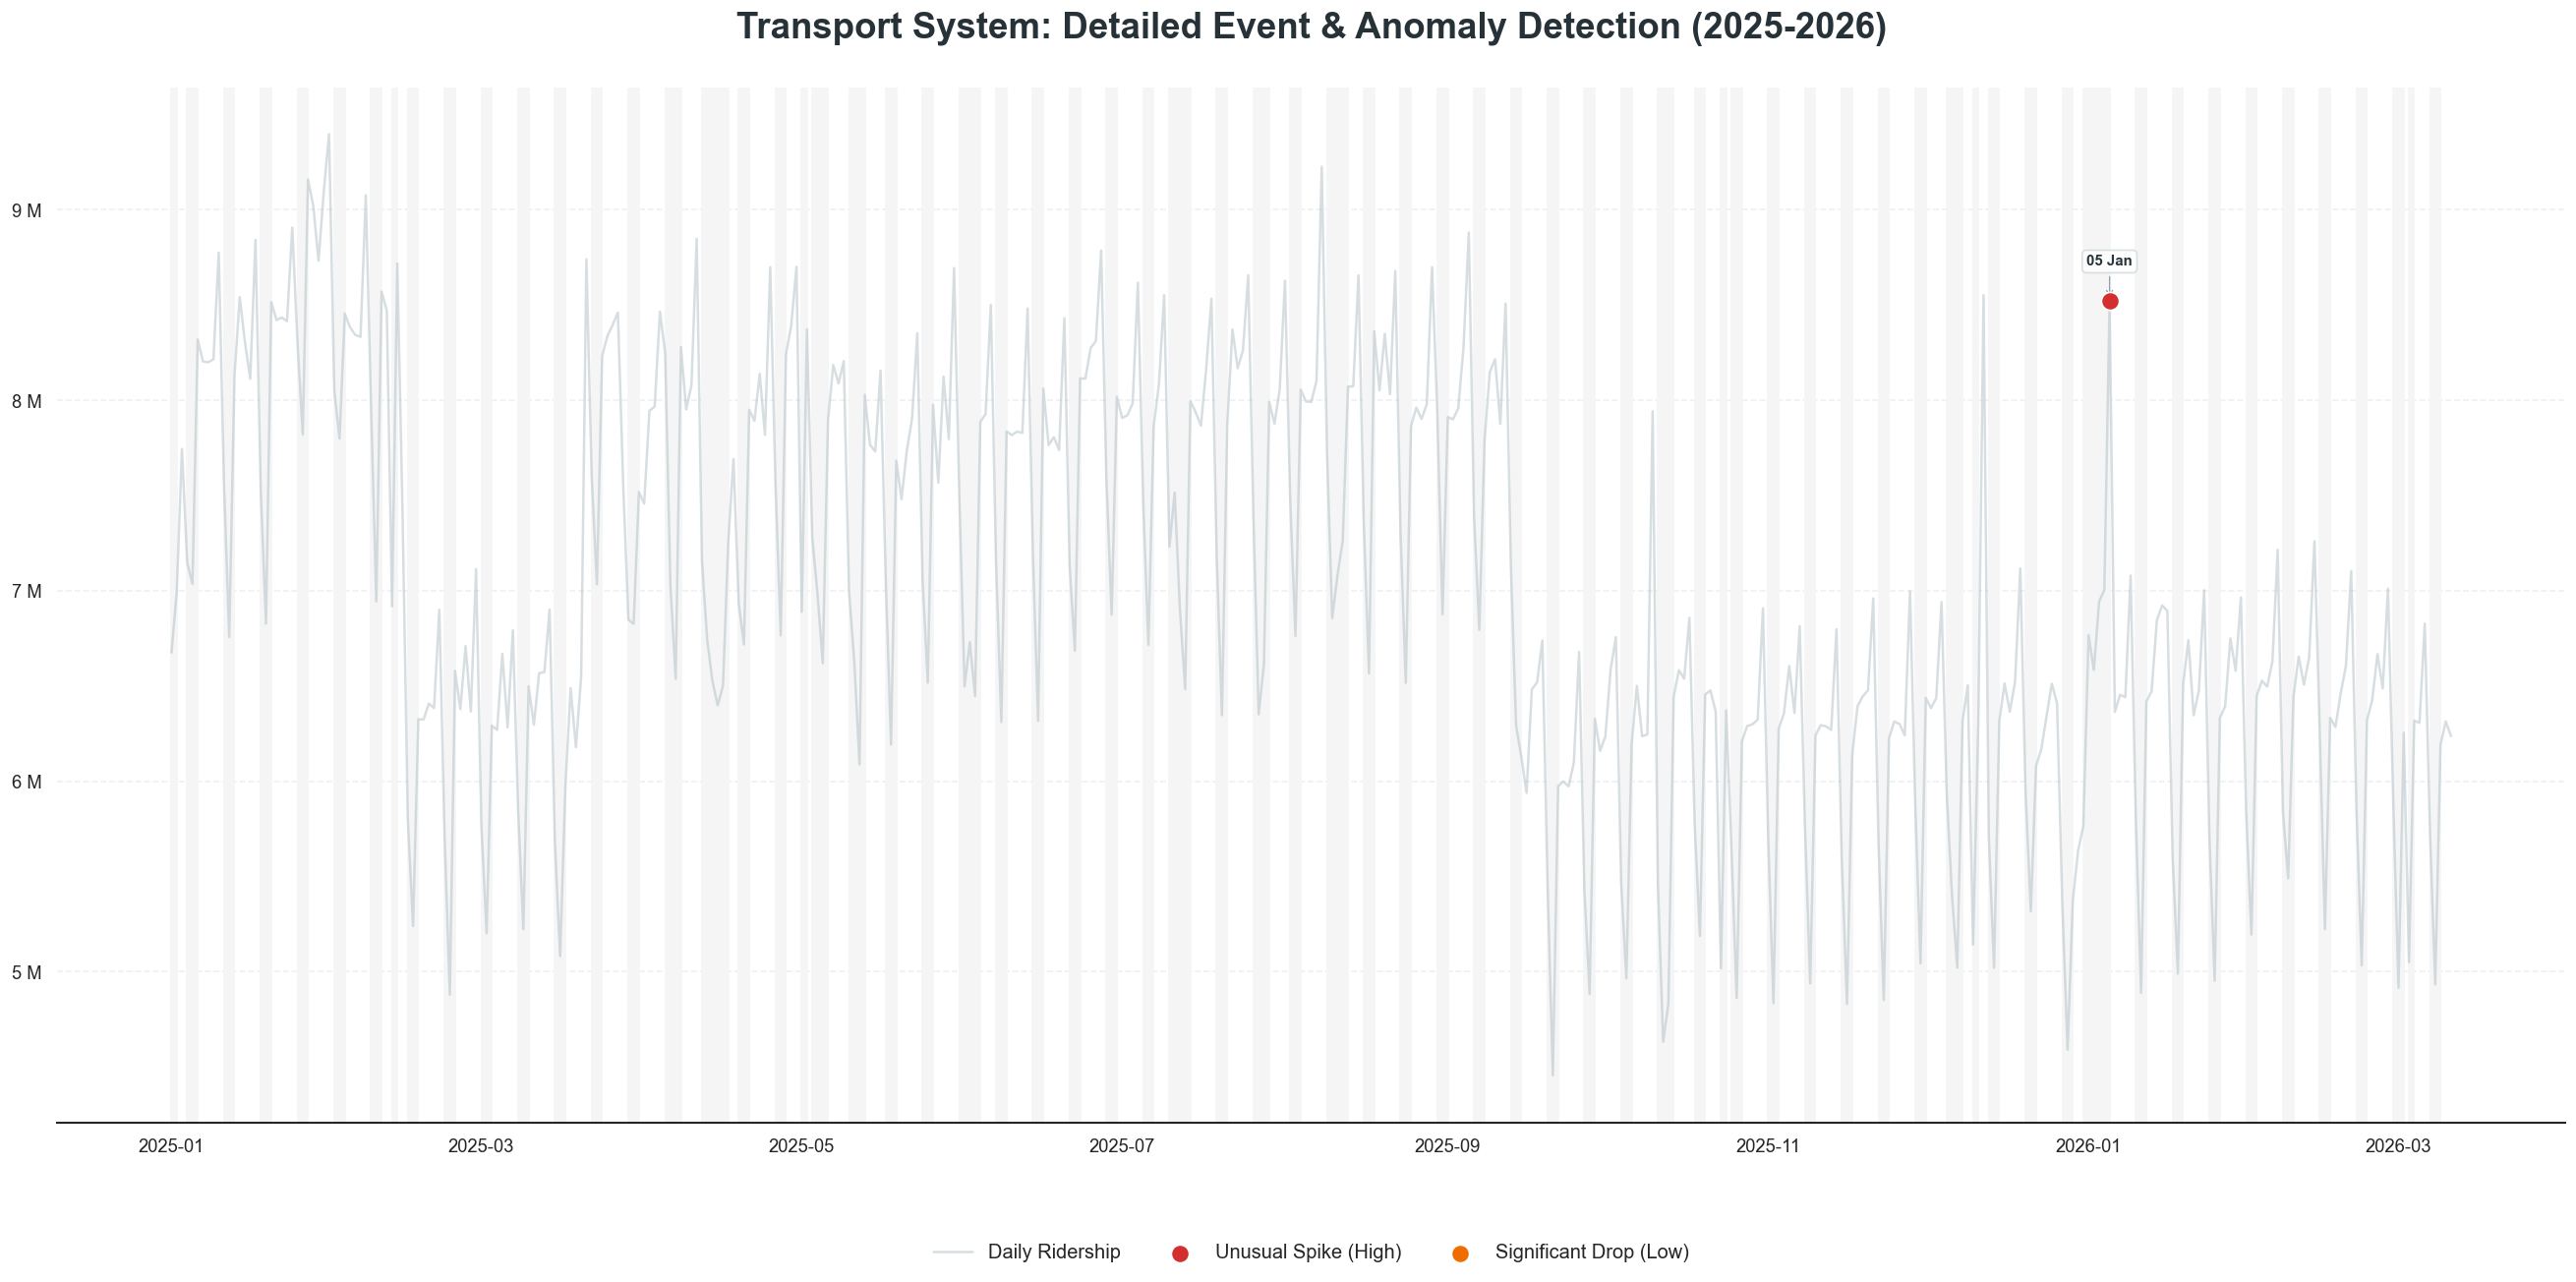

--- 📊 TOP 5 ANOMALY INSIGHTS ---

📅 วันที่: 2026-01-05 | ประเภท: Spike | เหตุการณ์: Normal Day/Special Event
📈 Z-Score: 2.14
หน่วยงาน                  ยานพาหนะ/ท่า          diff  percent_increase
    กทพ.   รถยนต์เฉพาะ 4 ล้อ (ทางด่วน) 242442.540984         16.314655
    กทพ.     รถยนต์ทุกประเภท (ทางด่วน) 199059.950820         12.898172
     ทล. รถยนต์ทุกประเภท (10 จุดสำรวจ)  78424.064516          8.110139
------------------------------------------------------------


In [104]:
df_all['วันที่'] = pd.to_datetime(df_all['วันที่'])
daily_df = df_all.groupby('วันที่')['ปริมาณ'].sum().reset_index().sort_values('วันที่')

# ดึงข้อมูลวันหยุดไทย ปี 2025-2026
th_holidays = holidays.Thailand(years=[2025, 2026])
daily_df['holiday_name'] = daily_df['วันที่'].apply(lambda x: th_holidays.get(x))
daily_df['is_holiday'] = daily_df['holiday_name'].notna()

# --- 2. คำนวณ Anomaly ด้วย Rolling Z-Score (Window 7 วัน) ---
window = 7
daily_df['rolling_mean'] = daily_df['ปริมาณ'].rolling(window=window, center=True).mean()
daily_df['rolling_std'] = daily_df['ปริมาณ'].rolling(window=window, center=True).std()
daily_df['z_score'] = (daily_df['ปริมาณ'] - daily_df['rolling_mean']) / daily_df['rolling_std']

threshold = 2
daily_df['is_anomaly'] = daily_df['z_score'].abs() > threshold
daily_df['anomaly_type'] = 'Normal'
daily_df.loc[(daily_df['is_anomaly']) & (daily_df['z_score'] > 0), 'anomaly_type'] = 'Spike'
daily_df.loc[(daily_df['is_anomaly']) & (daily_df['z_score'] < 0), 'anomaly_type'] = 'Drop'

# --- 3. การสร้าง Visualization ---
plt.figure(figsize=(22, 11))
sns.set_style("white")

# A. วาดแถบสีพื้นหลังสำหรับวันหยุด/เสาร์-อาทิตย์
for d in daily_df['วันที่']:
    if th_holidays.get(d) or d.weekday() >= 5:
        plt.axvspan(d, d + pd.Timedelta(days=1), color='#f5f5f5', zorder=1)

# B. วาดเส้นข้อมูลหลัก
plt.plot(daily_df['วันที่'], daily_df['ปริมาณ'], color='#b0bec5', linewidth=1.5, 
         label='Daily Ridership', alpha=0.5, zorder=2)

# C. วาดจุด Anomaly
spikes = daily_df[daily_df['anomaly_type'] == 'Spike']
drops = daily_df[daily_df['anomaly_type'] == 'Drop']

plt.scatter(spikes['วันที่'], spikes['ปริมาณ'], color='#d32f2f', s=120, edgecolors='white', 
            label='Unusual Spike (High)', zorder=6)
plt.scatter(drops['วันที่'], drops['ปริมาณ'], color='#ef6c00', s=120, edgecolors='white', 
            label='Significant Drop (Low)', zorder=6)

# D. ส่วนที่ปรับปรุง: ใส่ป้ายระบุชื่อเทศกาลหรือวันที่สำหรับ "ทุกจุด" ที่เป็น Anomaly
for i, row in daily_df[daily_df['is_anomaly']].iterrows():
    # กำหนดข้อความ: ถ้ามีชื่อวันหยุดให้ใช้ชื่อ ถ้าไม่มีให้ใช้วันที่
    if pd.notna(row['holiday_name']):
        label_text = row['holiday_name']
        box_color = '#e8f5e9' if row['anomaly_type'] == 'Spike' else '#fff3e0'
    else:
        label_text = row['วันที่'].strftime('%d %b') # เช่น 15 Oct
        box_color = 'white'

    # แยกทิศทางการวางป้าย (Spike ไว้ข้างบน, Drop ไว้ข้างล่าง)
    y_offset = 20 if row['anomaly_type'] == 'Spike' else -25
    va_type = 'bottom' if row['anomaly_type'] == 'Spike' else 'top'

    plt.annotate(label_text, 
                 (row['วันที่'], row['ปริมาณ']),
                 textcoords="offset points", 
                 xytext=(0, y_offset), 
                 ha='center', 
                 va=va_type,
                 fontsize=9, 
                 fontweight='bold', 
                 color='#263238',
                 arrowprops=dict(arrowstyle='->', color='#90a4ae', lw=0.8),
                 bbox=dict(boxstyle='round,pad=0.3', fc=box_color, ec='#cfd8dc', alpha=0.8))

# E. ปรับแต่งแกนและ Label
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.title('Transport System: Detailed Event & Anomaly Detection (2025-2026)', 
          fontsize=22, pad=30, fontweight='bold', color='#263238')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True)
plt.tight_layout()
plt.show()

# --- 4. สรุป Insight ออกมาเป็น Text Report ---
top_anomalies = daily_df[daily_df['is_anomaly']].sort_values(by='z_score', ascending=False).head(5)

print("--- 📊 TOP 5 ANOMALY INSIGHTS ---")
for _, row in top_anomalies.iterrows():
    t_date = row['วันที่']
    h_name = row['holiday_name'] if pd.notna(row['holiday_name']) else "Normal Day/Special Event"
    
    print(f"\n📅 วันที่: {t_date.strftime('%Y-%m-%d')} | ประเภท: {row['anomaly_type']} | เหตุการณ์: {h_name}")
    print(f"📈 Z-Score: {row['z_score']:.2f}")
    
    # ดึง Top 3 หน่วยงานที่มีส่วนต่างมากที่สุด
    detail = get_anomaly_insight(df_all, t_date)
    print(detail[['หน่วยงาน', 'ยานพาหนะ/ท่า', 'diff', 'percent_increase']].head(3).to_string(index=False))
    print("-" * 60)

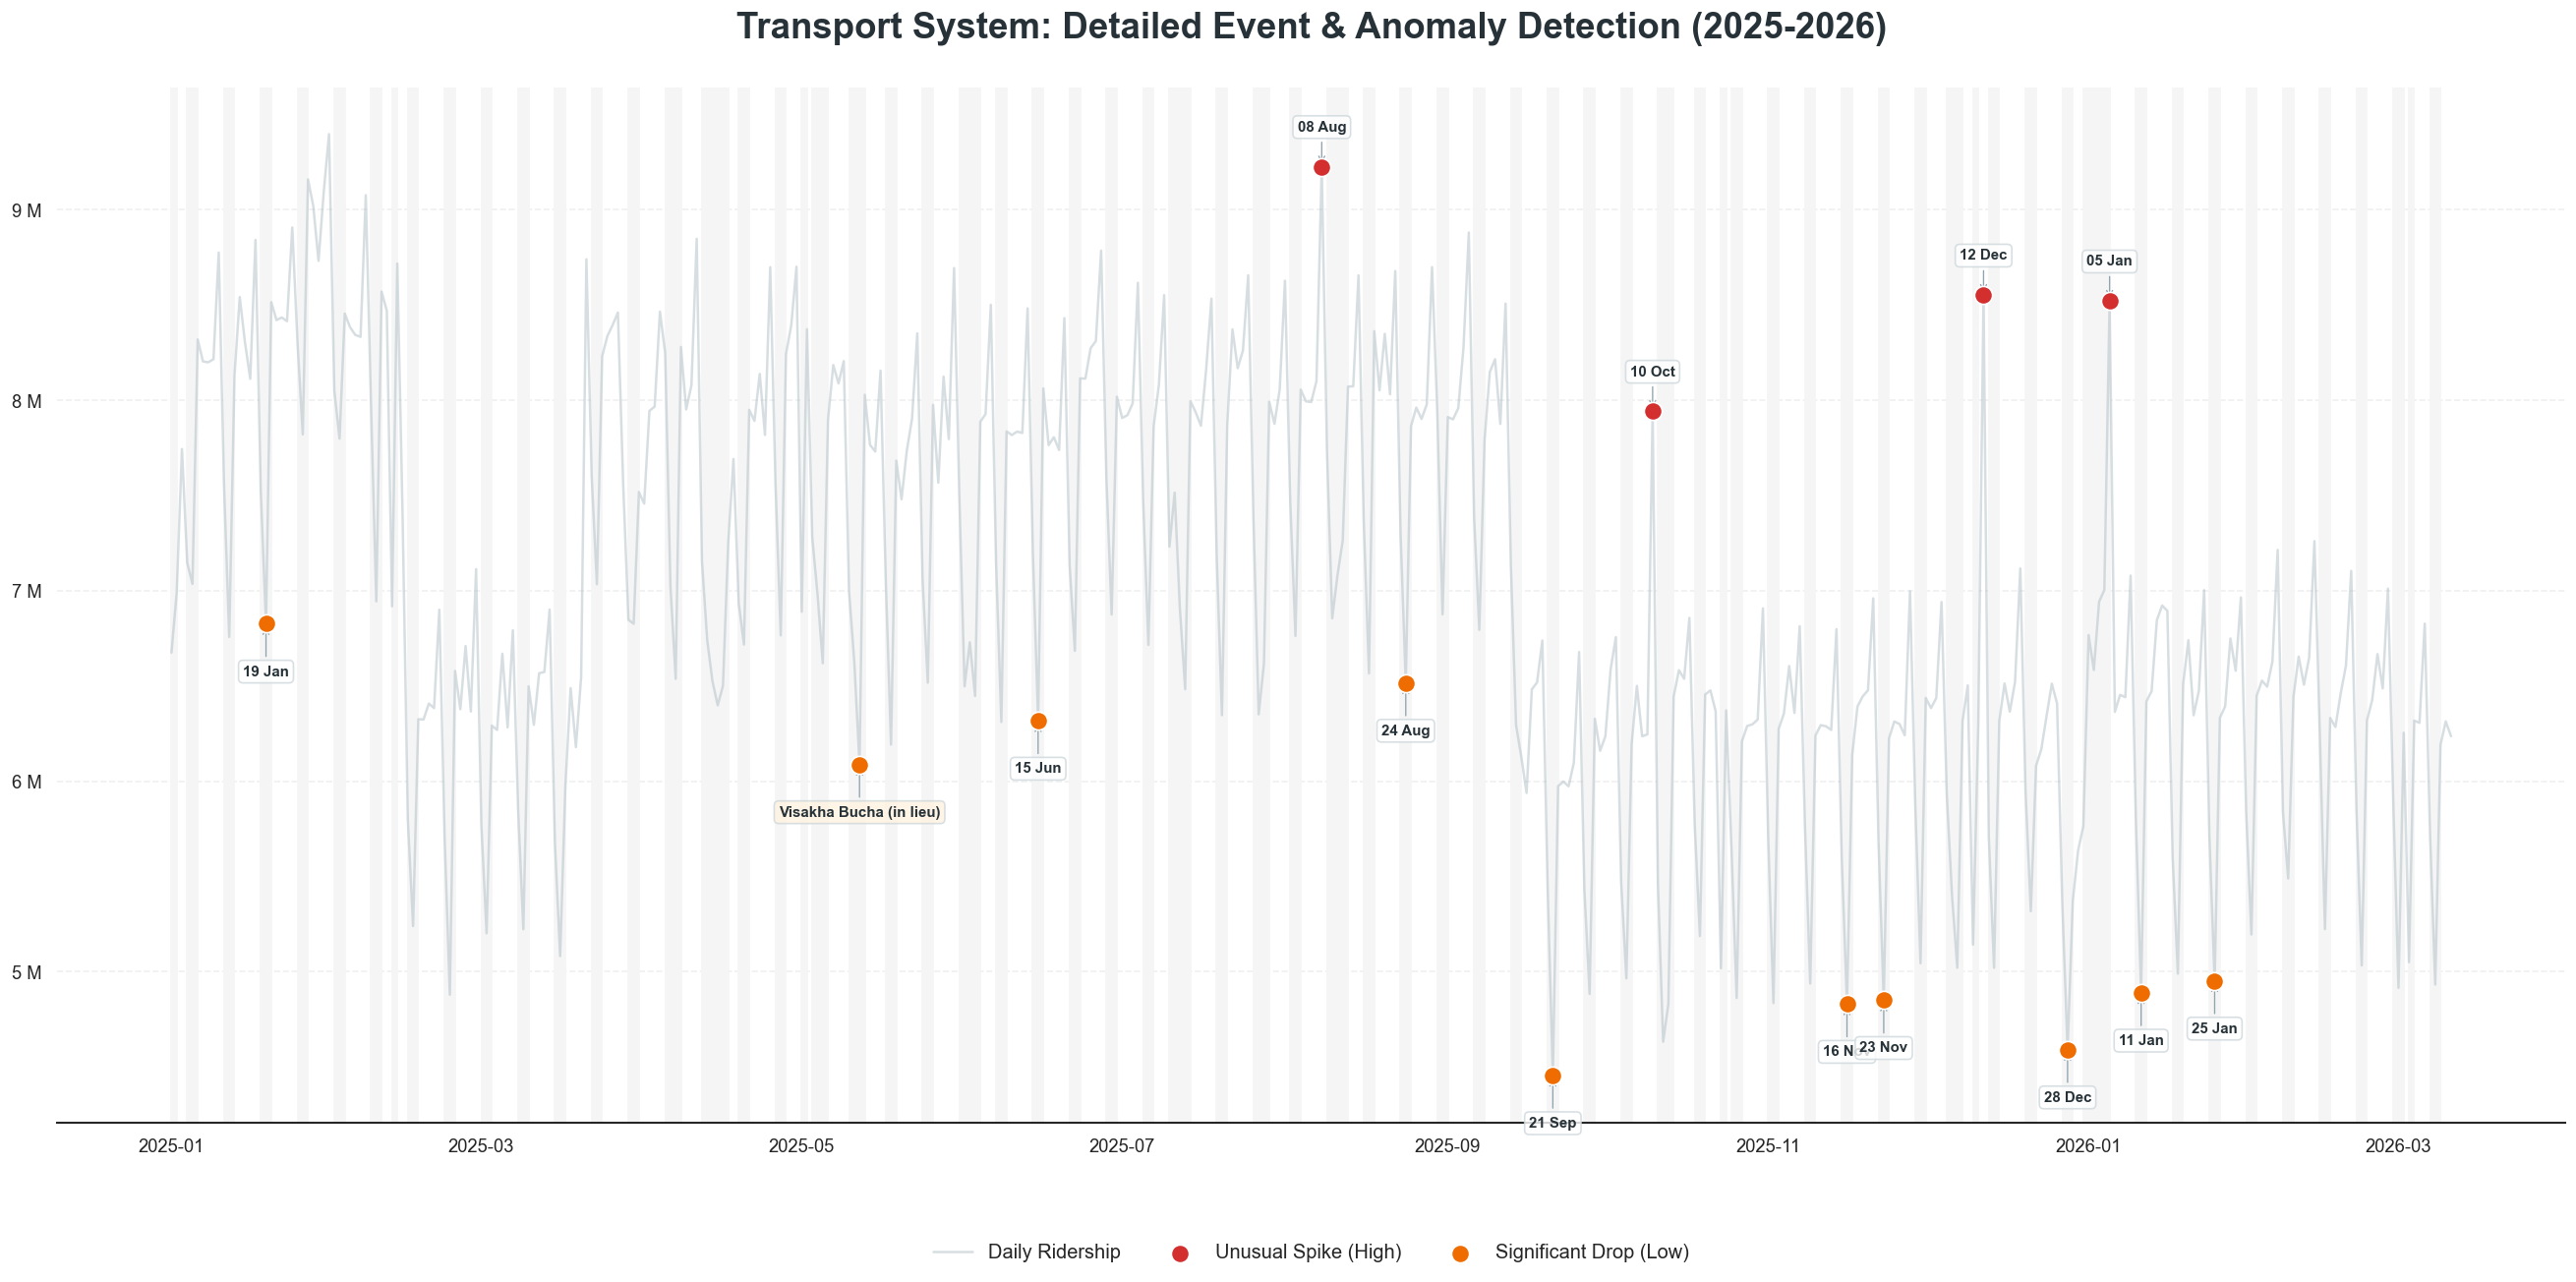

In [115]:
df_all['วันที่'] = pd.to_datetime(df_all['วันที่'])
daily_df = df_all.groupby('วันที่')['ปริมาณ'].sum().reset_index().sort_values('วันที่')

# ดึงข้อมูลวันหยุดไทย ปี 2025-2026
th_holidays = holidays.Thailand(years=[2025, 2026])
daily_df['holiday_name'] = daily_df['วันที่'].apply(lambda x: th_holidays.get(x))
daily_df['is_holiday'] = daily_df['holiday_name'].notna()

# --- 2. คำนวณ Anomaly ด้วย Rolling Z-Score (Window 7 วัน) ---
window = 21
daily_df['rolling_mean'] = daily_df['ปริมาณ'].rolling(window=window, center=True).mean()
daily_df['rolling_std'] = daily_df['ปริมาณ'].rolling(window=window, center=True).std()
daily_df['z_score'] = (daily_df['ปริมาณ'] - daily_df['rolling_mean']) / daily_df['rolling_std']

threshold_high = 2.0
threshold_low = 2.0

daily_df['is_anomaly'] = (daily_df['z_score'] > threshold_high) | (daily_df['z_score'] < -threshold_low)
daily_df['anomaly_type'] = 'Normal'
daily_df.loc[(daily_df['is_anomaly']) & (daily_df['z_score'] > 0), 'anomaly_type'] = 'Spike'
daily_df.loc[(daily_df['is_anomaly']) & (daily_df['z_score'] < 0), 'anomaly_type'] = 'Drop'

# --- 3. การสร้าง Visualization ---
plt.figure(figsize=(22, 11))
sns.set_style("white")

# A. วาดแถบสีพื้นหลังสำหรับวันหยุด/เสาร์-อาทิตย์
for d in daily_df['วันที่']:
    if th_holidays.get(d) or d.weekday() >= 5:
        plt.axvspan(d, d + pd.Timedelta(days=1), color='#f5f5f5', zorder=1)

# B. วาดเส้นข้อมูลหลัก
plt.plot(daily_df['วันที่'], daily_df['ปริมาณ'], color='#b0bec5', linewidth=1.5, 
         label='Daily Ridership', alpha=0.5, zorder=2)

# C. วาดจุด Anomaly
spikes = daily_df[daily_df['anomaly_type'] == 'Spike']
drops = daily_df[daily_df['anomaly_type'] == 'Drop']

plt.scatter(spikes['วันที่'], spikes['ปริมาณ'], color='#d32f2f', s=120, edgecolors='white', 
            label='Unusual Spike (High)', zorder=6)
plt.scatter(drops['วันที่'], drops['ปริมาณ'], color='#ef6c00', s=120, edgecolors='white', 
            label='Significant Drop (Low)', zorder=6)

# D. ส่วนที่ปรับปรุง: ใส่ป้ายระบุชื่อเทศกาลหรือวันที่สำหรับ "ทุกจุด" ที่เป็น Anomaly
for i, row in daily_df[daily_df['is_anomaly']].iterrows():
    # กำหนดข้อความ: ถ้ามีชื่อวันหยุดให้ใช้ชื่อ ถ้าไม่มีให้ใช้วันที่
    if pd.notna(row['holiday_name']):
        label_text = row['holiday_name']
        box_color = '#e8f5e9' if row['anomaly_type'] == 'Spike' else '#fff3e0'
    else:
        label_text = row['วันที่'].strftime('%d %b') # เช่น 15 Oct
        box_color = 'white'

    # แยกทิศทางการวางป้าย (Spike ไว้ข้างบน, Drop ไว้ข้างล่าง)
    y_offset = 20 if row['anomaly_type'] == 'Spike' else -25
    va_type = 'bottom' if row['anomaly_type'] == 'Spike' else 'top'

    plt.annotate(label_text, 
                 (row['วันที่'], row['ปริมาณ']),
                 textcoords="offset points", 
                 xytext=(0, y_offset), 
                 ha='center', 
                 va=va_type,
                 fontsize=9, 
                 fontweight='bold', 
                 color='#263238',
                 arrowprops=dict(arrowstyle='->', color='#90a4ae', lw=0.8),
                 bbox=dict(boxstyle='round,pad=0.3', fc=box_color, ec='#cfd8dc', alpha=0.8))

# E. ปรับแต่งแกนและ Label
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.title('Transport System: Detailed Event & Anomaly Detection (2025-2026)', 
          fontsize=22, pad=30, fontweight='bold', color='#263238')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True)
plt.tight_layout()
plt.show()

In [117]:
def get_anomaly_insight(full_data, target_date):
    """
    ฟังก์ชันคำนวณว่าในวันที่เกิด Anomaly หน่วยงานไหนที่มีการเปลี่ยนแปลงมากที่สุด
    เทียบกับค่าเฉลี่ยของ 'วันในสัปดาห์เดียวกัน' (Baseline)
    """
    target_date = pd.to_datetime(target_date)
    # 1. ข้อมูลของวันที่เกิด Anomaly
    anomaly_day_data = full_data[full_data['วันที่'] == target_date]
    
    # 2. คำนวณ Baseline: หาค่าเฉลี่ยของวันในสัปดาห์เดียวกัน (เช่น ถ้าเป้าหมายคือวันจันทร์ ก็หาค่าเฉลี่ยวันจันทร์อื่นๆ)
    day_of_week = target_date.dayofweek
    # เลือกข้อมูลที่ไม่ใช่วันที่เป้าหมาย แต่เป็นวันเดียวกันในสัปดาห์
    baseline_days = full_data[(full_data['วันที่'].dt.dayofweek == day_of_week) & 
                              (full_data['วันที่'] != target_date)]
    
    # คำนวณค่าเฉลี่ยแยกตามหน่วยงานและประเภทรถ
    baseline_avg = baseline_days.groupby(['หน่วยงาน', 'ยานพาหนะ/ท่า'])['ปริมาณ'].mean().reset_index()
    baseline_avg.rename(columns={'ปริมาณ': 'avg_volume'}, inplace=True)
    
    # 3. รวมข้อมูลเพื่อเปรียบเทียบ
    current_data = anomaly_day_data.groupby(['หน่วยงาน', 'ยานพาหนะ/ท่า'])['ปริมาณ'].sum().reset_index()
    insight_df = pd.merge(current_data, baseline_avg, on=['หน่วยงาน', 'ยานพาหนะ/ท่า'], how='left')
    
    # 4. คำนวณส่วนต่าง
    insight_df['diff'] = insight_df['ปริมาณ'] - insight_df['avg_volume']
    insight_df['percent_increase'] = (insight_df['diff'] / insight_df['avg_volume']) * 100
    
    # เรียงลำดับตามความเบี่ยงเบน (ใช้ค่าสัมบูรณ์เพื่อให้เห็นทั้ง Spike และ Drop ที่ส่งผลกระทบสูง)
    return insight_df.reindex(insight_df['diff'].abs().sort_values(ascending=False).index)

# --- ส่วนการดึงข้อมูลและ Print Report ---

# เลือก Top 5 Anomaly ที่มีค่า Z-Score รุนแรงที่สุด (ทั้งบวกและลบ)
top_anomalies = daily_df[daily_df['is_anomaly']].copy()
top_anomalies['abs_z'] = top_anomalies['z_score'].abs()
top_anomalies = top_anomalies.sort_values(by='abs_z', ascending=False).head(10)

print("\n" + "="*70)
print("--- 📊 TOP 5 ANOMALY INSIGHTS (Deep Dive by Agency) ---")
print("="*70)

for _, row in top_anomalies.iterrows():
    t_date = row['วันที่']
    h_name = row['holiday_name'] if pd.notna(row['holiday_name']) else "Normal Day/Special Event"
    
    print(f"\n📅 วันที่: {t_date.strftime('%Y-%m-%d')} ({t_date.day_name()})")
    print(f"🚩 ประเภท: {row['anomaly_type']} | เหตุการณ์: {h_name}")
    print(f"📈 Z-Score: {row['z_score']:.2f}")
    print(f"{'-'*30}")
    
    # เรียกใช้ฟังก์ชันเพื่อดูว่า 'ใคร' คือต้นเหตุที่ทำให้ยอดพุ่งหรือวูบ
    detail = get_anomaly_insight(df_all, t_date)
    
    # แสดงผล 3 อันดับแรกที่ส่งผลต่อค่าความผิดปกตินี้มากที่สุด
    print(detail[['หน่วยงาน', 'ยานพาหนะ/ท่า', 'diff', 'percent_increase']].head(3).to_string(index=False, float_format=lambda x: f"{x:,.2f}"))
    print("-" * 70)


--- 📊 TOP 5 ANOMALY INSIGHTS (Deep Dive by Agency) ---

📅 วันที่: 2025-12-12 (Friday)
🚩 ประเภท: Spike | เหตุการณ์: Normal Day/Special Event
📈 Z-Score: 2.93
------------------------------
หน่วยงาน               ยานพาหนะ/ท่า         diff  percent_increase
    กทพ.  รถยนต์ทุกประเภท (ทางด่วน) 1,740,287.11             98.38
    รฟม.        รถไฟฟ้าสายสีน้ำเงิน    20,692.31              4.19
     ขบ. รถเอกชนเส้นปฏิรูป (หมวด 1)    19,707.13              5.47
----------------------------------------------------------------------

📅 วันที่: 2026-01-05 (Monday)
🚩 ประเภท: Spike | เหตุการณ์: Normal Day/Special Event
📈 Z-Score: 2.53
------------------------------
หน่วยงาน                ยานพาหนะ/ท่า        diff  percent_increase
    กทพ. รถยนต์เฉพาะ 4 ล้อ (ทางด่วน)  242,442.54             16.31
    กทพ.   รถยนต์ทุกประเภท (ทางด่วน)  199,059.95             12.90
   ขสมก.                รถเมล์ ขสมก. -174,091.72            -33.59
----------------------------------------------------------------------

📅